# Minimum Description Length



## Setup

In [1]:
# Core dependencies

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
from scipy.optimize import minimize_scalar, minimize
from scipy.special import gammaln, comb
from scipy.stats import norm, multivariate_normal
from itertools import product as iterproduct
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 150,
    'font.size': 11,
    'font.family': 'serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette (consistent with previous Information Theory notebooks)
BLUE = '#2563EB'
RED = '#DC2626'
GREEN = '#059669'
AMBER = '#D97706'
PURPLE = '#7C3AED'
SLATE = '#475569'
TEAL = '#0F6E56'
LIGHT_BLUE = '#DBEAFE'
LIGHT_RED = '#FEE2E2'
LIGHT_GREEN = '#D1FAE5'
LIGHT_AMBER = '#FEF3C7'
LIGHT_PURPLE = '#EDE9FE'

# Reproducibility
rng = np.random.default_rng(42)

# === Core information-theoretic functions (reused from earlier notebooks) ===

def entropy(probs):
    """Shannon entropy H(X) in bits. Convention: 0 log 0 = 0."""
    p = np.asarray(probs, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def kl_divergence(p, q):
    """D_KL(p || q) in bits."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    mask = p > 0
    if np.any(q[mask] <= 0):
        return np.inf
    return np.sum(p[mask] * np.log2(p[mask] / q[mask]))

def log_star(n):
    """Rissanen's universal code length for positive integers.
    L*(n) = log2(n) + log2(log2(n)) + ... (sum positive terms) + log2(c0).
    Approximation: log2(n) + log2(log2(n)) + 2.865 for practical use."""
    if n <= 0:
        return 0.0
    total = np.log2(2.865)  # log2(c0) ≈ log2(2.865)
    val = np.log2(float(n))
    while val > 0:
        total += val
        val = np.log2(val)
    return total

def nml_complexity_gaussian(n, k):
    """Parametric complexity COMP(M_k) for k-parameter Gaussian model.
    Asymptotic form: COMP ≈ (k/2) log(n/(2π)) + log(π^{k/2} / Gamma(k/2)).
    For linear regression with k parameters and known variance."""
    if k == 0:
        return 0.0
    return 0.5 * k * np.log2(n / (2 * np.pi)) + np.log2(np.pi ** (k / 2) / np.exp(gammaln(k / 2)))

def bic_score(log_likelihood, n, k):
    """BIC = -2 log L + k log n."""
    return -2 * log_likelihood + k * np.log(n)

def aic_score(log_likelihood, k):
    """AIC = -2 log L + 2k."""
    return -2 * log_likelihood + 2 * k

print("Setup complete. NumPy version:", np.__version__)


Setup complete. NumPy version: 2.4.3


---

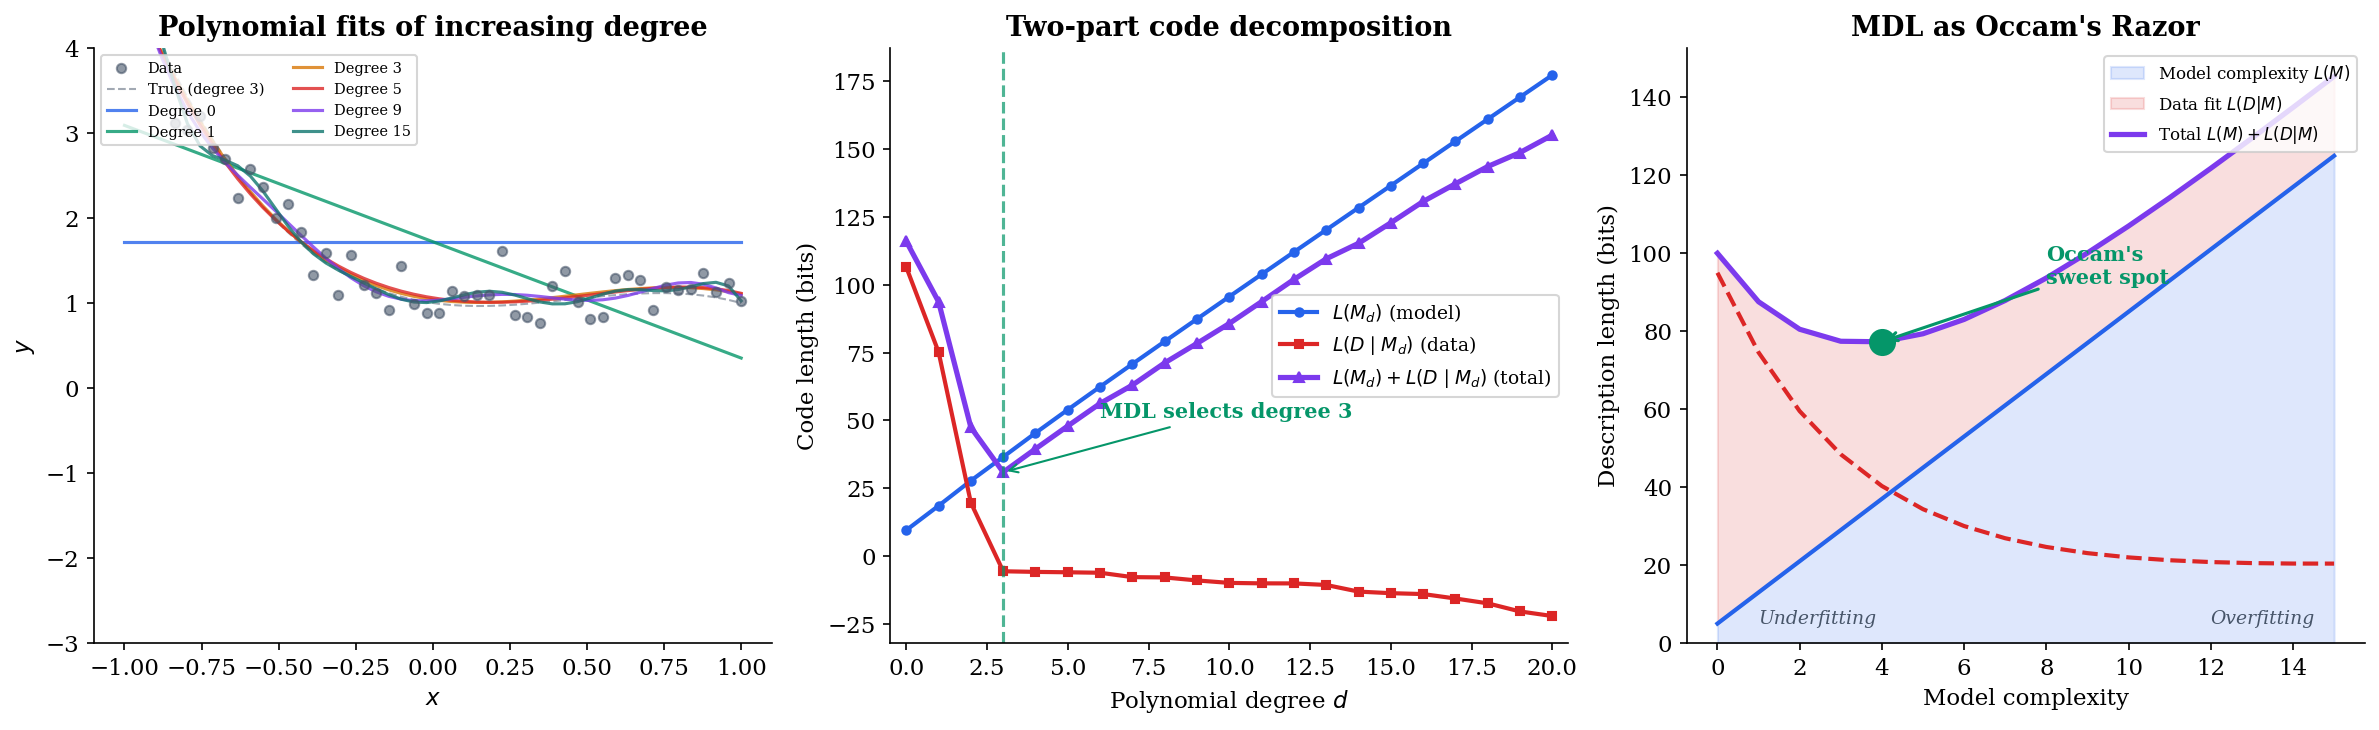

In [2]:
# === Two-Part Codes & Crude MDL ===
# The Minimum Description Length principle formalizes Occam's Razor:
# the best model is the one that provides the shortest TOTAL description
# of the data. We split the description into two parts:
#
#     L(M) + L(D | M)
#
# where L(M) = code length for the model (complexity penalty) and
# L(D | M) = code length for the data given the model (goodness of fit).
#
# A simple model has small L(M) but large L(D|M) (poor fit).
# A complex model has large L(M) but small L(D|M) (good fit, but overfit).
# MDL selects the model minimizing the sum — the optimal trade-off.
#
# ──────────────────────────────────────────────────────────────────────────
# Definition 1 (Two-Part Code / Crude MDL).
# Given a model class M = {M_1, M_2, ...} and data D = x^n = (x_1, ..., x_n),
# the crude MDL estimator selects:
#
#     M* = arg min_{M_k ∈ M} [ L(M_k) + L(x^n | M_k) ]
#
# where:
#   L(M_k) = code length for the model index k plus its parameters θ_k
#   L(x^n | M_k) = -log₂ p(x^n | θ̂_k, M_k), the negative log-likelihood
#                   evaluated at the MLE θ̂_k
# ──────────────────────────────────────────────────────────────────────────
#
# ──────────────────────────────────────────────────────────────────────────
# Definition 2 (Universal Code for Integers).
# Rissanen's universal code assigns code length L*(k) to positive integer k:
#
#     L*(k) = log₂(k) + log₂(log₂(k)) + ... + log₂(c₀)
#
# where we sum only positive terms, and c₀ ≈ 2.865 is a normalizing constant.
# This is a valid prefix code for all positive integers.
# ──────────────────────────────────────────────────────────────────────────
#
# EXAMPLE: Polynomial regression model selection.
# Consider fitting polynomials of degree 0, 1, ..., d_max to noisy data.
# For a degree-d polynomial: k = d + 1 parameters.
#   L(M_d) = L*(d) + (d + 1) * (precision bits per parameter)
#   L(D | M_d) = -(n/2) log₂(2πe σ̂²) where σ̂² = RSS / n
#
# The total description length trades off complexity vs fit.

# Generate synthetic data: true model is degree 3
np.random.seed(42)
n = 50
x = np.linspace(-1, 1, n)
true_coeffs = [1.0, -0.5, 2.0, -1.5]  # degree 3
y_true = sum(c * x**i for i, c in enumerate(true_coeffs))
sigma_noise = 0.3
y = y_true + rng.normal(0, sigma_noise, n)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Data and polynomial fits ---
ax = axes[0]
ax.scatter(x, y, s=20, color=SLATE, alpha=0.6, zorder=3, label='Data')
ax.plot(x, y_true, '--', color=SLATE, alpha=0.5, linewidth=1, label='True (degree 3)')

colors_poly = [BLUE, GREEN, AMBER, RED, PURPLE, '#0F766E', '#BE185D']
degrees = [0, 1, 3, 5, 9, 15]
for d, color in zip(degrees, colors_poly):
    coeffs = np.polyfit(x, y, d)
    y_fit = np.polyval(coeffs, x)
    ax.plot(x, y_fit, color=color, linewidth=1.5, alpha=0.8, label=f'Degree {d}')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Polynomial fits of increasing degree', fontweight='bold')
ax.legend(fontsize=7, loc='upper left', ncol=2)
ax.set_ylim(-3, 4)

# --- Panel 2: Two-part code decomposition ---
ax = axes[1]
max_degree = 20
d_range = np.arange(0, max_degree + 1)
precision = 8  # bits per parameter (quantized to 1/256 precision)

model_lengths = []
data_lengths = []
total_lengths = []

for d in d_range:
    k = d + 1
    # Model code: L*(k) + k * precision
    L_model = log_star(k) + k * precision
    
    # Data code: -log₂ p(x^n | θ̂, M_d) = (n/2) log₂(2πe σ̂²)
    coeffs = np.polyfit(x, y, d)
    y_fit = np.polyval(coeffs, x)
    rss = np.sum((y - y_fit) ** 2)
    sigma2_hat = rss / n
    L_data = 0.5 * n * np.log2(2 * np.pi * np.e * max(sigma2_hat, 1e-15))
    
    model_lengths.append(L_model)
    data_lengths.append(L_data)
    total_lengths.append(L_model + L_data)

model_lengths = np.array(model_lengths)
data_lengths = np.array(data_lengths)
total_lengths = np.array(total_lengths)

ax.plot(d_range, model_lengths, 'o-', color=BLUE, linewidth=2, markersize=4, label='$L(M_d)$ (model)')
ax.plot(d_range, data_lengths, 's-', color=RED, linewidth=2, markersize=4, label='$L(D \mid M_d)$ (data)')
ax.plot(d_range, total_lengths, '^-', color=PURPLE, linewidth=2.5, markersize=5, label='$L(M_d) + L(D \mid M_d)$ (total)')

best_d = d_range[np.argmin(total_lengths)]
ax.axvline(x=best_d, color=GREEN, linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate(f'MDL selects degree {best_d}', xy=(best_d, total_lengths[best_d]),
            xytext=(best_d + 3, total_lengths[best_d] + 20),
            arrowprops=dict(arrowstyle='->', color=GREEN), fontsize=10, color=GREEN, fontweight='bold')

ax.set_xlabel('Polynomial degree $d$')
ax.set_ylabel('Code length (bits)')
ax.set_title('Two-part code decomposition', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.5, max_degree + 0.5)

# --- Panel 3: Model complexity vs goodness-of-fit trade-off diagram ---
ax = axes[2]
# Conceptual diagram: the bias-variance-description-length connection

d_conceptual = np.arange(0, 16)
# Model complexity grows linearly
complexity = 5 + 8 * d_conceptual
# Data fit improves then plateaus
fit_cost = 80 * np.exp(-0.3 * d_conceptual) + 15 + 0.3 * d_conceptual
# Total
total_conceptual = complexity + fit_cost

ax.fill_between(d_conceptual, 0, complexity, alpha=0.15, color=BLUE, label='Model complexity $L(M)$')
ax.fill_between(d_conceptual, complexity, complexity + fit_cost, alpha=0.15, color=RED, label='Data fit $L(D|M)$')
ax.plot(d_conceptual, complexity, color=BLUE, linewidth=2)
ax.plot(d_conceptual, fit_cost, color=RED, linewidth=2, linestyle='--')
ax.plot(d_conceptual, total_conceptual, color=PURPLE, linewidth=2.5, label='Total $L(M) + L(D|M)$')

opt_idx = np.argmin(total_conceptual)
ax.plot(d_conceptual[opt_idx], total_conceptual[opt_idx], 'o', color=GREEN, markersize=12, zorder=5)
ax.annotate("Occam's\nsweet spot", xy=(d_conceptual[opt_idx], total_conceptual[opt_idx]),
            xytext=(d_conceptual[opt_idx] + 4, total_conceptual[opt_idx] + 15),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5),
            fontsize=10, color=GREEN, fontweight='bold')

# Underfitting / overfitting regions
ax.text(1, 5, 'Underfitting', fontsize=9, color=SLATE, style='italic')
ax.text(12, 5, 'Overfitting', fontsize=9, color=SLATE, style='italic')

ax.set_xlabel('Model complexity')
ax.set_ylabel('Description length (bits)')
ax.set_title("MDL as Occam's Razor", fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig('mdl_two_part_codes.png', dpi=150, bbox_inches='tight')
plt.show()


---

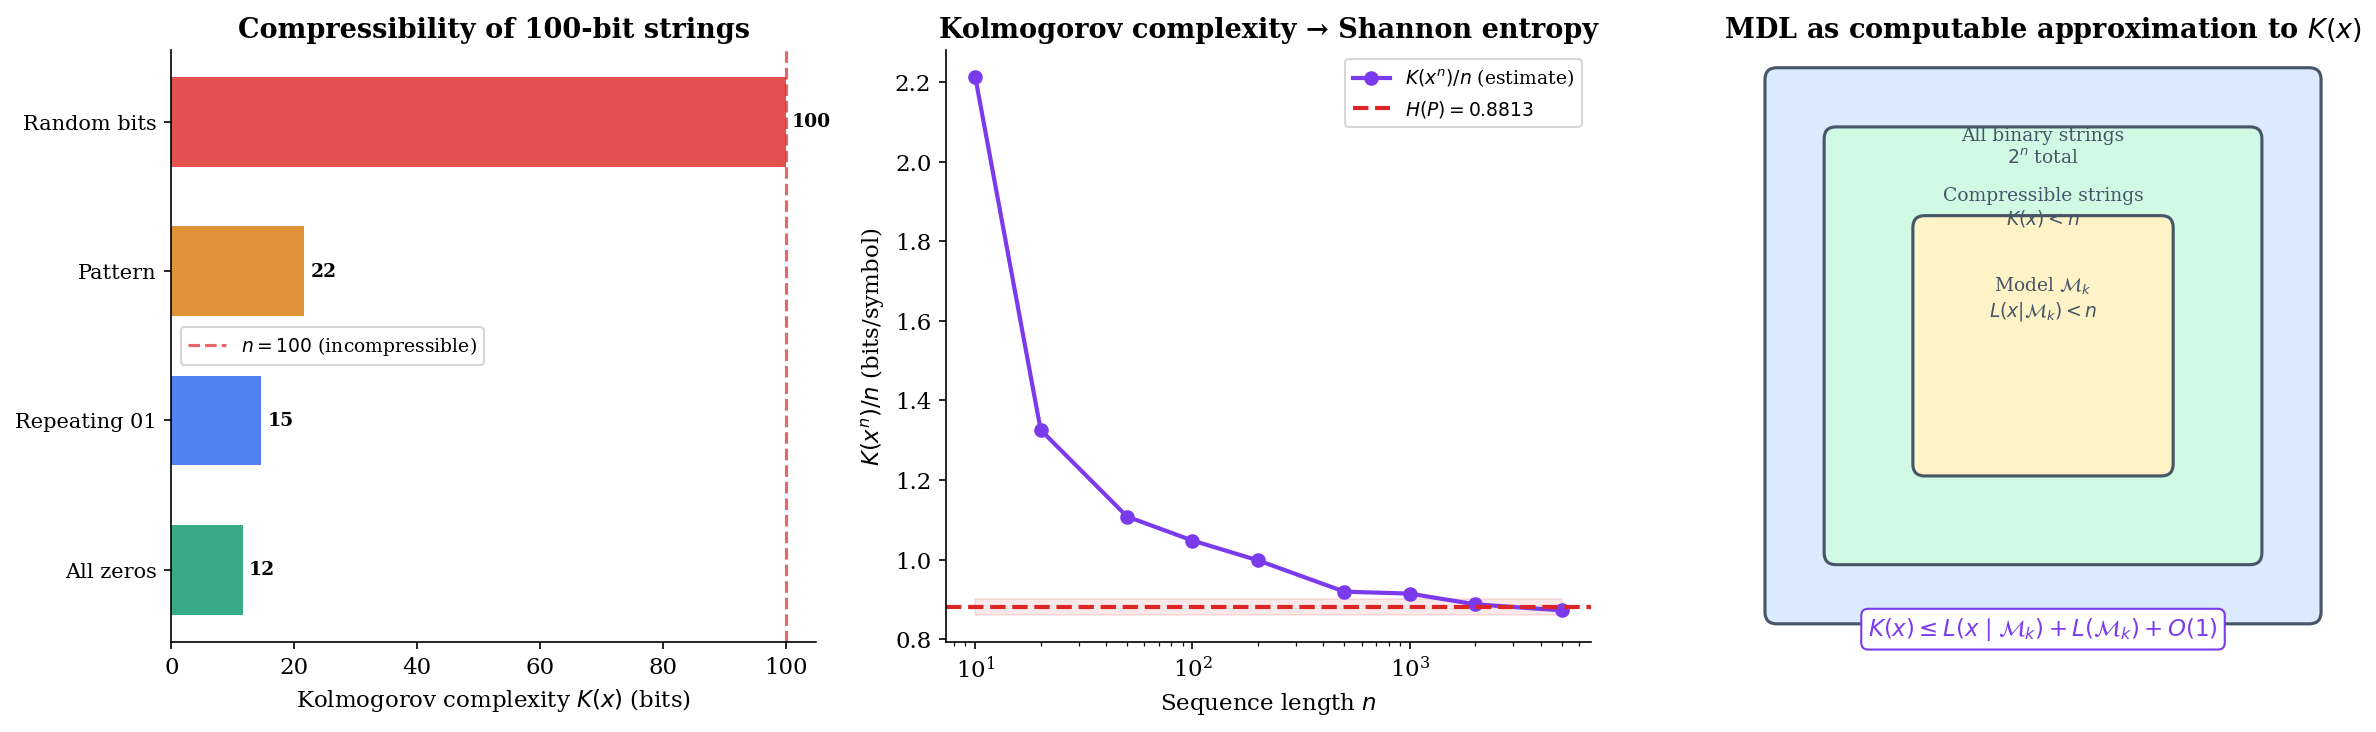

In [3]:
# === Kolmogorov Complexity & Algorithmic Information ===
# The ideal MDL would use Kolmogorov complexity K(x) — the length of the
# shortest program that produces x on a universal Turing machine.
# K(x) is the ultimate measure of compressibility: it captures ALL
# regularities, including ones no finite model class can express.
#
# ──────────────────────────────────────────────────────────────────────────
# Definition 3 (Kolmogorov Complexity).
# The Kolmogorov complexity K_U(x) of a string x with respect to a
# universal Turing machine U is:
#
#     K_U(x) = min { |p| : U(p) = x }
#
# where the minimum is over all programs p that produce x, and |p| is the
# length of p in bits.
# ──────────────────────────────────────────────────────────────────────────
#
# ──────────────────────────────────────────────────────────────────────────
# Theorem 1 (Invariance Theorem).
# For any two universal Turing machines U₁ and U₂, there exists a constant
# c (depending on U₁, U₂ but NOT on x) such that:
#
#     |K_{U₁}(x) - K_{U₂}(x)| ≤ c    for all x
#
# Proof. U₁ can simulate U₂ by prepending a fixed interpreter program of
# length c. Thus K_{U₁}(x) ≤ K_{U₂}(x) + c. Symmetrically, K_{U₂}(x) ≤
# K_{U₁}(x) + c'. Taking c = max(c, c') gives the result.  ∎
# ──────────────────────────────────────────────────────────────────────────
#
# CRITICAL PROBLEM: K(x) is NOT computable. There is no algorithm that
# takes an arbitrary string x and outputs K(x). This is equivalent to the
# halting problem.
#
# SOLUTION: MDL replaces K(x) with the code length under a specified model
# class. This gives a COMPUTABLE upper bound on K(x) and a practical
# criterion for model selection.
#
# ──────────────────────────────────────────────────────────────────────────
# Proposition 1 (Kolmogorov Complexity and Entropy).
# If X₁, ..., Xₙ are i.i.d. ~ P, then:
#
#     (1/n) K(X₁...Xₙ) → H(P)   almost surely as n → ∞
#
# Kolmogorov complexity converges to Shannon entropy for i.i.d. data.
# This connects the algorithmic (individual-sequence) viewpoint to the
# probabilistic (ensemble) viewpoint.
# ──────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Compressibility of different strings ---
ax = axes[0]
strings = [
    ('0' * 100, 'All zeros'),
    ('01' * 50, 'Repeating 01'),
    ('0001011011' * 10, 'Pattern'),
    (None, 'Random bits'),  # placeholder for random
]

complexities = []
labels = []
for s, label in strings:
    if s is None:
        # Random string — approximately incompressible
        complexity = 100  # K(x) ≈ n for random strings
    else:
        # Estimate: length of a description
        if label == 'All zeros':
            complexity = np.log2(100) + 5  # "print 0, 100 times"
        elif label == 'Repeating 01':
            complexity = np.log2(100) + 8  # "print 01, 50 times"
        elif label == 'Pattern':
            complexity = np.log2(100) + 15  # longer program
    complexities.append(complexity)
    labels.append(label)

colors_k = [GREEN, BLUE, AMBER, RED]
bars = ax.barh(range(len(labels)), complexities, color=colors_k, alpha=0.8, height=0.6)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Kolmogorov complexity $K(x)$ (bits)', fontsize=11)
ax.set_title('Compressibility of 100-bit strings', fontweight='bold')
ax.axvline(x=100, color=RED, linestyle='--', linewidth=1.5, alpha=0.7, label='$n=100$ (incompressible)')
ax.legend(fontsize=9)

for i, v in enumerate(complexities):
    ax.text(v + 1, i, f'{v:.0f}', va='center', fontsize=9, fontweight='bold')

# --- Panel 2: K(x^n)/n converges to H(P) ---
ax = axes[1]
# Simulate: for i.i.d. Bernoulli(0.3), K(x^n)/n → H(0.3)
p_true = 0.3
H_true = -p_true * np.log2(p_true) - (1 - p_true) * np.log2(1 - p_true)

ns = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000])
# Approximate K(x^n)/n by empirical entropy + overhead/n
K_over_n = []
for ni in ns:
    # Generate i.i.d. data
    data = rng.binomial(1, p_true, ni)
    counts = np.bincount(data, minlength=2)
    empirical_p = counts / ni
    H_empirical = entropy(empirical_p)
    # K(x^n)/n ≈ H_empirical + O(log n / n) overhead
    overhead = (np.log2(ni) + 10) / ni
    K_over_n.append(H_empirical + overhead)

ax.semilogx(ns, K_over_n, 'o-', color=PURPLE, linewidth=2, markersize=6, label='$K(x^n)/n$ (estimate)')
ax.axhline(y=H_true, color=RED, linestyle='--', linewidth=2, label=f'$H(P) = {H_true:.4f}$')

ax.fill_between(ns, H_true - 0.02, H_true + 0.02, alpha=0.1, color=RED)
ax.set_xlabel('Sequence length $n$')
ax.set_ylabel('$K(x^n)/n$ (bits/symbol)')
ax.set_title('Kolmogorov complexity → Shannon entropy', fontweight='bold')
ax.legend(fontsize=9)

# --- Panel 3: MDL hierarchy ---
ax = axes[2]
# Conceptual diagram: K(x) ≤ L*(x|M) for any model M
# Show that model-based code lengths upper-bound K(x)

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('MDL as computable approximation to $K(x)$', fontweight='bold')

# Draw nested rectangles
rects = [
    (0.5, 0.5, 9, 9, LIGHT_BLUE, 'All binary strings\n$2^n$ total'),
    (1.5, 1.5, 7, 7, LIGHT_GREEN, 'Compressible strings\n$K(x) < n$'),
    (3.0, 3.0, 4, 4, LIGHT_AMBER, 'Model $\mathcal{M}_k$\n$L(x|\mathcal{M}_k) < n$'),
]

for x0, y0, w, h, color, label in rects:
    rect = FancyBboxPatch((x0, y0), w, h, boxstyle="round,pad=0.2",
                          facecolor=color, edgecolor=SLATE, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x0 + w/2, y0 + h - 0.8, label, ha='center', va='top', fontsize=9, color=SLATE)

# Key inequality
ax.text(5, 0.1, '$K(x) \leq L(x \mid \mathcal{M}_k) + L(\mathcal{M}_k) + O(1)$',
        ha='center', fontsize=11, fontweight='bold', color=PURPLE,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=PURPLE))

plt.tight_layout()
plt.savefig('mdl_kolmogorov.png', dpi=150, bbox_inches='tight')
plt.show()


---

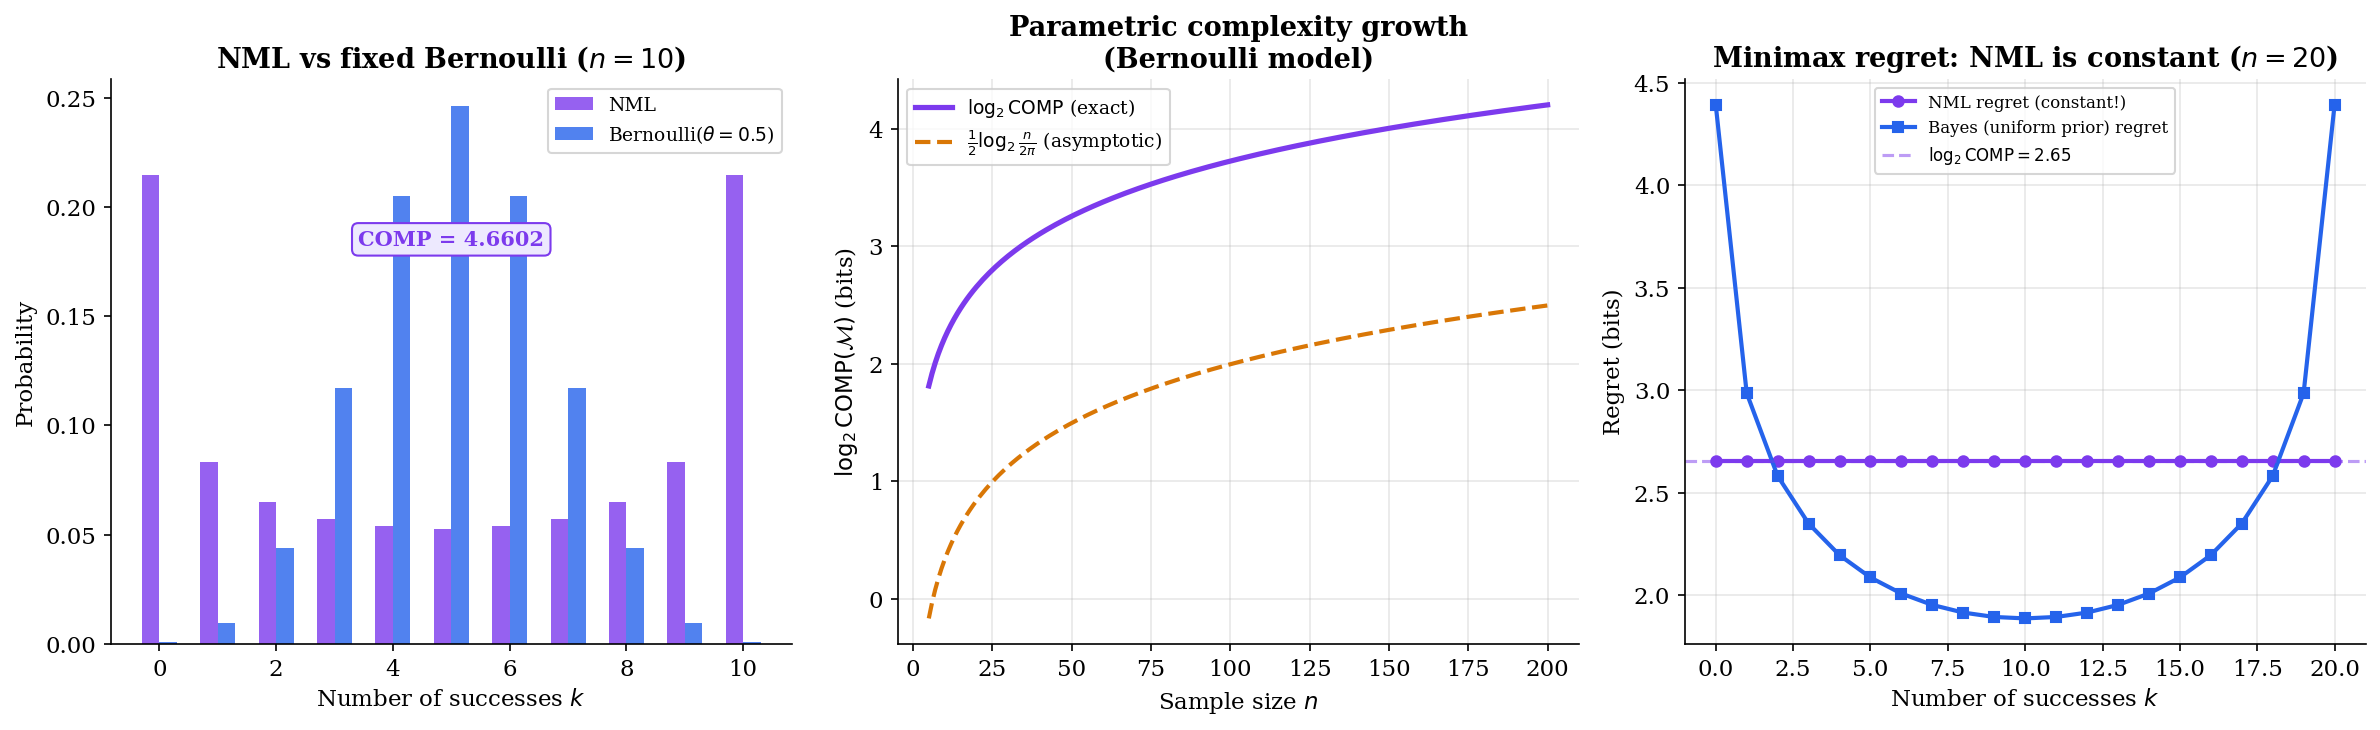

In [4]:
# === Stochastic Complexity & Refined MDL ===
# Crude MDL has a weakness: the model code length L(M_k) depends on
# arbitrary choices (parameter precision, prior over models). Refined MDL
# eliminates this arbitrariness by defining a single "universal model" that
# achieves the minimax regret.
#
# ──────────────────────────────────────────────────────────────────────────
# Definition 4 (Stochastic Complexity).
# The stochastic complexity of data x^n relative to model class M_k
# (with parameter space Θ_k) is:
#
#     SC(x^n ; M_k) = -log₂ p_NML(x^n | M_k)
#
# where p_NML is the Normalized Maximum Likelihood (NML) distribution.
# ──────────────────────────────────────────────────────────────────────────
#
# ──────────────────────────────────────────────────────────────────────────
# Definition 5 (Normalized Maximum Likelihood / NML).
# The NML distribution is defined as:
#
#     p_NML(x^n | M_k) = p(x^n | θ̂(x^n), M_k) / COMP(M_k)
#
# where θ̂(x^n) is the MLE for the specific data x^n, and the normalizing
# constant (parametric complexity) is:
#
#     COMP(M_k) = Σ_{z^n} p(z^n | θ̂(z^n), M_k)
#
# summing over ALL possible data sequences z^n.
# ──────────────────────────────────────────────────────────────────────────
#
# ──────────────────────────────────────────────────────────────────────────
# Theorem 2 (Shtarkov's Minimax Optimality).
# The NML distribution minimizes the worst-case regret:
#
#     p_NML = arg min_q  max_{x^n}  [ -log q(x^n) - (-log p(x^n | θ̂(x^n))) ]
#
# and the minimax regret equals log₂ COMP(M_k).
#
# Proof sketch. The regret of any code q relative to the MLE is:
#   R(q, x^n) = log p(x^n | θ̂(x^n)) - log q(x^n)
# = log [p(x^n | θ̂(x^n)) / q(x^n)].
#
# Setting q = p_NML:
#   R(p_NML, x^n) = log p(x^n | θ̂(x^n)) - log[p(x^n | θ̂(x^n))/COMP]
#   = log COMP(M_k).
#
# This is constant for ALL x^n, hence it achieves the minimax:
# no code can have lower worst-case regret.  ∎
# ──────────────────────────────────────────────────────────────────────────
#
# The stochastic complexity decomposes as:
#     SC(x^n ; M_k) = -log₂ p(x^n | θ̂(x^n)) + log₂ COMP(M_k)
#                   = [maximized neg-log-likelihood] + [parametric complexity]
#
# This is similar to crude MDL but with COMP replacing the arbitrary L(M_k).

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: NML vs MLE for Bernoulli model ---
ax = axes[0]
# For Bernoulli with n observations: x^n has k successes
# MLE: θ̂ = k/n
# p(x^n | θ̂) = (k/n)^k ((n-k)/n)^(n-k) * C(n,k) ... but we use the
# likelihood at MLE (without the binomial coefficient)
# COMP(Bernoulli, n) = sum_{k=0}^{n} C(n,k) (k/n)^k ((n-k)/n)^(n-k)

n_bern = 10
k_range = np.arange(0, n_bern + 1)

# MLE likelihoods (unnormalized)
mle_likelihoods = []
for k in k_range:
    theta_hat = k / n_bern
    if k == 0:
        lik = 1.0 ** n_bern  # (1-0)^n
    elif k == n_bern:
        lik = 1.0 ** n_bern  # 1^n
    else:
        lik = theta_hat**k * (1 - theta_hat)**(n_bern - k)
    # Multiply by binomial coefficient for probability over sequences
    binom_coeff = float(comb(n_bern, k, exact=True))
    mle_likelihoods.append(binom_coeff * lik)

mle_likelihoods = np.array(mle_likelihoods)
COMP = np.sum(mle_likelihoods)
nml_probs = mle_likelihoods / COMP

# Compare: MLE at θ=0.5 (uniform prior viewpoint)
mle_at_half = np.array([float(comb(n_bern, k, exact=True)) * 0.5**n_bern for k in k_range])

ax.bar(k_range - 0.15, nml_probs, width=0.3, color=PURPLE, alpha=0.8, label='NML')
ax.bar(k_range + 0.15, mle_at_half, width=0.3, color=BLUE, alpha=0.8, label='Bernoulli($\\theta=0.5$)')

ax.set_xlabel('Number of successes $k$')
ax.set_ylabel('Probability')
ax.set_title(f'NML vs fixed Bernoulli ($n={n_bern}$)', fontweight='bold')
ax.legend(fontsize=9)
ax.text(5, max(nml_probs) * 0.85, f'COMP = {COMP:.4f}', fontsize=10, ha='center',
        color=PURPLE, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor=LIGHT_PURPLE, edgecolor=PURPLE))

# --- Panel 2: Parametric complexity growth ---
ax = axes[1]
ns_comp = np.arange(5, 201)

# COMP for Bernoulli model (k=1 parameter)
comp_bernoulli = []
for ni in ns_comp:
    comp = 0.0
    for k in range(ni + 1):
        theta = k / ni if k > 0 and k < ni else (0.5 / ni if k == 0 else (ni - 0.5) / ni)
        if k == 0:
            lik = 1.0
        elif k == ni:
            lik = 1.0
        else:
            theta_hat = k / ni
            lik = theta_hat**k * (1 - theta_hat)**(ni - k)
        binom_c = float(comb(ni, k, exact=True))
        comp += binom_c * lik
    comp_bernoulli.append(comp)

comp_bernoulli = np.array(comp_bernoulli)
log_comp_bernoulli = np.log2(comp_bernoulli)

# Asymptotic: COMP ~ sqrt(n/(2π)) for Bernoulli
asymptotic = 0.5 * np.log2(ns_comp / (2 * np.pi))

ax.plot(ns_comp, log_comp_bernoulli, color=PURPLE, linewidth=2.5, label='$\log_2 \mathrm{COMP}$ (exact)')
ax.plot(ns_comp, asymptotic, '--', color=AMBER, linewidth=2, label='$\\frac{1}{2}\log_2 \\frac{n}{2\pi}$ (asymptotic)')

ax.set_xlabel('Sample size $n$')
ax.set_ylabel('$\log_2 \mathrm{COMP}(\mathcal{M})$ (bits)')
ax.set_title('Parametric complexity growth\n(Bernoulli model)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Panel 3: Regret is constant for NML ---
ax = axes[2]
n_regret = 20
k_vals = np.arange(0, n_regret + 1)

# Compute regret for NML and for Bayes with uniform prior
mle_liks = []
for k in k_vals:
    theta_hat = k / n_regret
    if k == 0 or k == n_regret:
        lik = 1.0
    else:
        lik = theta_hat**k * (1 - theta_hat)**(n_regret - k)
    binom_c = float(comb(n_regret, k, exact=True))
    mle_liks.append(binom_c * lik)

mle_liks = np.array(mle_liks)
COMP_20 = np.sum(mle_liks)
nml_20 = mle_liks / COMP_20

# Bayes with uniform (Beta(1,1)) prior: p(k|n) = 1/(n+1) for all k
bayes_uniform = np.ones(n_regret + 1) / (n_regret + 1)

# Regret = log(MLE likelihood) - log(code probability)
regret_nml = np.log2(mle_liks) - np.log2(nml_20)
regret_bayes = np.log2(mle_liks) - np.log2(bayes_uniform)

ax.plot(k_vals, regret_nml, 'o-', color=PURPLE, linewidth=2, markersize=5, label='NML regret (constant!)')
ax.plot(k_vals, regret_bayes, 's-', color=BLUE, linewidth=2, markersize=5, label='Bayes (uniform prior) regret')

ax.axhline(y=np.log2(COMP_20), color=PURPLE, linestyle='--', alpha=0.5,
           label=f'$\log_2 \mathrm{{COMP}} = {np.log2(COMP_20):.2f}$')

ax.set_xlabel('Number of successes $k$')
ax.set_ylabel('Regret (bits)')
ax.set_title(f'Minimax regret: NML is constant ($n={n_regret}$)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mdl_nml_stochastic_complexity.png', dpi=150, bbox_inches='tight')
plt.show()


---

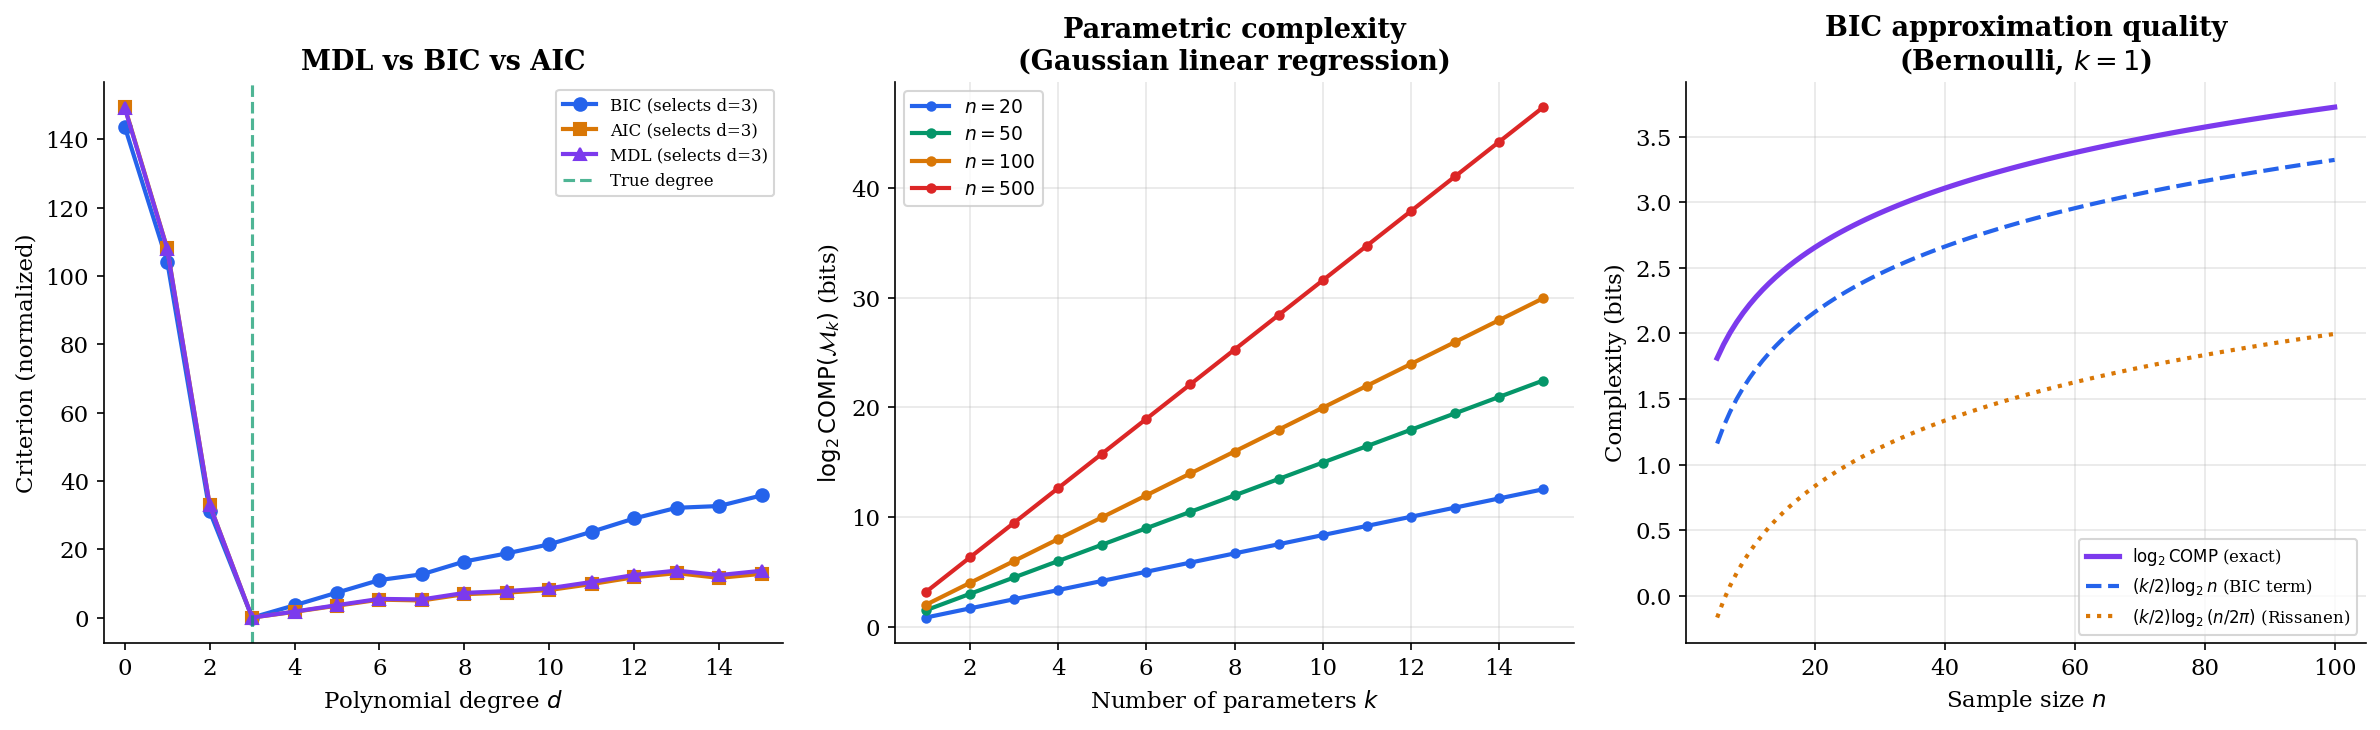

In [5]:
# === Fisher Information & Parametric Complexity ===
# For exponential family models, the parametric complexity COMP has a clean
# asymptotic form that connects to the Fisher information matrix.
#
# ──────────────────────────────────────────────────────────────────────────
# Theorem 3 (Asymptotic Parametric Complexity — Rissanen 1996).
# For a k-dimensional exponential family model with Fisher information
# matrix I(θ), as n → ∞:
#
#     log COMP(M_k) = (k/2) log(n/(2π)) + log ∫ √det(I(θ)) dθ + o(1)
#
# where the integral is over the parameter space Θ_k.
# ──────────────────────────────────────────────────────────────────────────
#
# This reveals the GEOMETRIC interpretation of model complexity:
# - The first term (k/2) log(n) grows with dimension — more parameters = more complex
# - The integral ∫ √det(I(θ)) dθ is the VOLUME of the model manifold in
#   the Fisher metric — it measures how many "distinguishable" distributions
#   the model contains
#
# ──────────────────────────────────────────────────────────────────────────
# Corollary 1 (Stochastic Complexity ≈ BIC + geometry).
# Substituting the asymptotic COMP into the stochastic complexity:
#
#     SC(x^n) ≈ -log p(x^n | θ̂) + (k/2) log n
#             + [(k/2) log(1/(2π)) + log ∫ √det I(θ) dθ]
#
# The first two terms are exactly (1/2) × BIC. The bracketed term is the
# geometric correction that BIC ignores. For large n, BIC dominates.
# ──────────────────────────────────────────────────────────────────────────
#
# ──────────────────────────────────────────────────────────────────────────
# Proposition 2 (BIC as Crude MDL Approximation).
# The Bayesian Information Criterion BIC = -2 log L(θ̂) + k log n
# is equivalent (up to O(1) terms) to twice the stochastic complexity:
#
#     BIC ≈ 2 × SC(x^n ; M_k)
#
# BIC can be viewed as a rough MDL criterion that uses (k/2) log n bits
# for the model complexity, ignoring the Fisher information geometry.
# ──────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: BIC vs AIC vs MDL for polynomial regression ---
ax = axes[0]
max_d = 15
degrees_sel = np.arange(0, max_d + 1)

bic_vals = []
aic_vals = []
mdl_vals = []  # refined MDL (stochastic complexity approximation)

for d in degrees_sel:
    k = d + 1  # number of parameters (including intercept) + noise variance
    k_total = k + 1  # +1 for σ²
    coeffs = np.polyfit(x, y, d)
    y_fit = np.polyval(coeffs, x)
    rss = np.sum((y - y_fit) ** 2)
    sigma2_hat = rss / n
    
    # Log-likelihood (Gaussian)
    log_lik = -0.5 * n * (np.log(2 * np.pi * sigma2_hat) + 1)
    
    bic_vals.append(bic_score(log_lik, n, k_total))
    aic_vals.append(aic_score(log_lik, k_total))
    
    # Refined MDL: SC ≈ -log L(θ̂) + (k/2) log(n/(2π)) + Fisher correction
    sc = -log_lik + 0.5 * k_total * np.log(n / (2 * np.pi))
    mdl_vals.append(2 * sc)  # scale to match BIC convention

bic_vals = np.array(bic_vals)
aic_vals = np.array(aic_vals)
mdl_vals = np.array(mdl_vals)

# Normalize for comparison (subtract minimum)
bic_norm = bic_vals - bic_vals.min()
aic_norm = aic_vals - aic_vals.min()
mdl_norm = mdl_vals - mdl_vals.min()

ax.plot(degrees_sel, bic_norm, 'o-', color=BLUE, linewidth=2, label=f'BIC (selects d={degrees_sel[np.argmin(bic_vals)]})')
ax.plot(degrees_sel, aic_norm, 's-', color=AMBER, linewidth=2, label=f'AIC (selects d={degrees_sel[np.argmin(aic_vals)]})')
ax.plot(degrees_sel, mdl_norm, '^-', color=PURPLE, linewidth=2, label=f'MDL (selects d={degrees_sel[np.argmin(mdl_vals)]})')

ax.axvline(x=3, color=GREEN, linestyle='--', linewidth=1.5, alpha=0.7, label='True degree')
ax.set_xlabel('Polynomial degree $d$')
ax.set_ylabel('Criterion (normalized)')
ax.set_title('MDL vs BIC vs AIC', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(-0.5, max_d + 0.5)

# --- Panel 2: Fisher information volume for Gaussian location family ---
ax = axes[1]
# For N(μ, σ²) with both unknown: I(θ) = diag(1/σ², 1/(2σ⁴))
# Volume element: √det I = 1/(σ² √2)
# For Gaussian linear regression with k predictors and known σ²:
# COMP ≈ (n/(2π))^{k/2} × volume_correction

ks = np.arange(1, 16)
ns_plot = [20, 50, 100, 500]
colors_n = [BLUE, GREEN, AMBER, RED]

for ni, color in zip(ns_plot, colors_n):
    log_comp = 0.5 * ks * np.log2(ni / (2 * np.pi))
    ax.plot(ks, log_comp, 'o-', color=color, linewidth=2, markersize=4,
            label=f'$n = {ni}$')

ax.set_xlabel('Number of parameters $k$')
ax.set_ylabel('$\log_2 \mathrm{COMP}(\mathcal{M}_k)$ (bits)')
ax.set_title('Parametric complexity\n(Gaussian linear regression)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Panel 3: Asymptotic breakdown: BIC vs exact COMP ---
ax = axes[2]
ns_comp2 = np.arange(5, 101)

# For Bernoulli model: exact COMP and BIC approximation
log_comp_exact = []
for ni in ns_comp2:
    comp = 0.0
    for k in range(ni + 1):
        if k == 0 or k == ni:
            lik = 1.0
        else:
            theta_hat = k / ni
            lik = theta_hat**k * (1 - theta_hat)**(ni - k)
        binom_c = float(comb(ni, k, exact=True))
        comp += binom_c * lik
    log_comp_exact.append(np.log2(comp))

log_comp_exact = np.array(log_comp_exact)
bic_approx = 0.5 * np.log2(ns_comp2)  # (k/2) log₂ n with k=1

ax.plot(ns_comp2, log_comp_exact, color=PURPLE, linewidth=2.5, label='$\log_2 \mathrm{COMP}$ (exact)')
ax.plot(ns_comp2, bic_approx, '--', color=BLUE, linewidth=2, label='$(k/2)\log_2 n$ (BIC term)')
ax.plot(ns_comp2, 0.5 * np.log2(ns_comp2 / (2 * np.pi)), ':', color=AMBER, linewidth=2,
        label='$(k/2)\log_2(n/2\pi)$ (Rissanen)')

ax.set_xlabel('Sample size $n$')
ax.set_ylabel('Complexity (bits)')
ax.set_title('BIC approximation quality\n(Bernoulli, $k=1$)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mdl_fisher_bic.png', dpi=150, bbox_inches='tight')
plt.show()


---

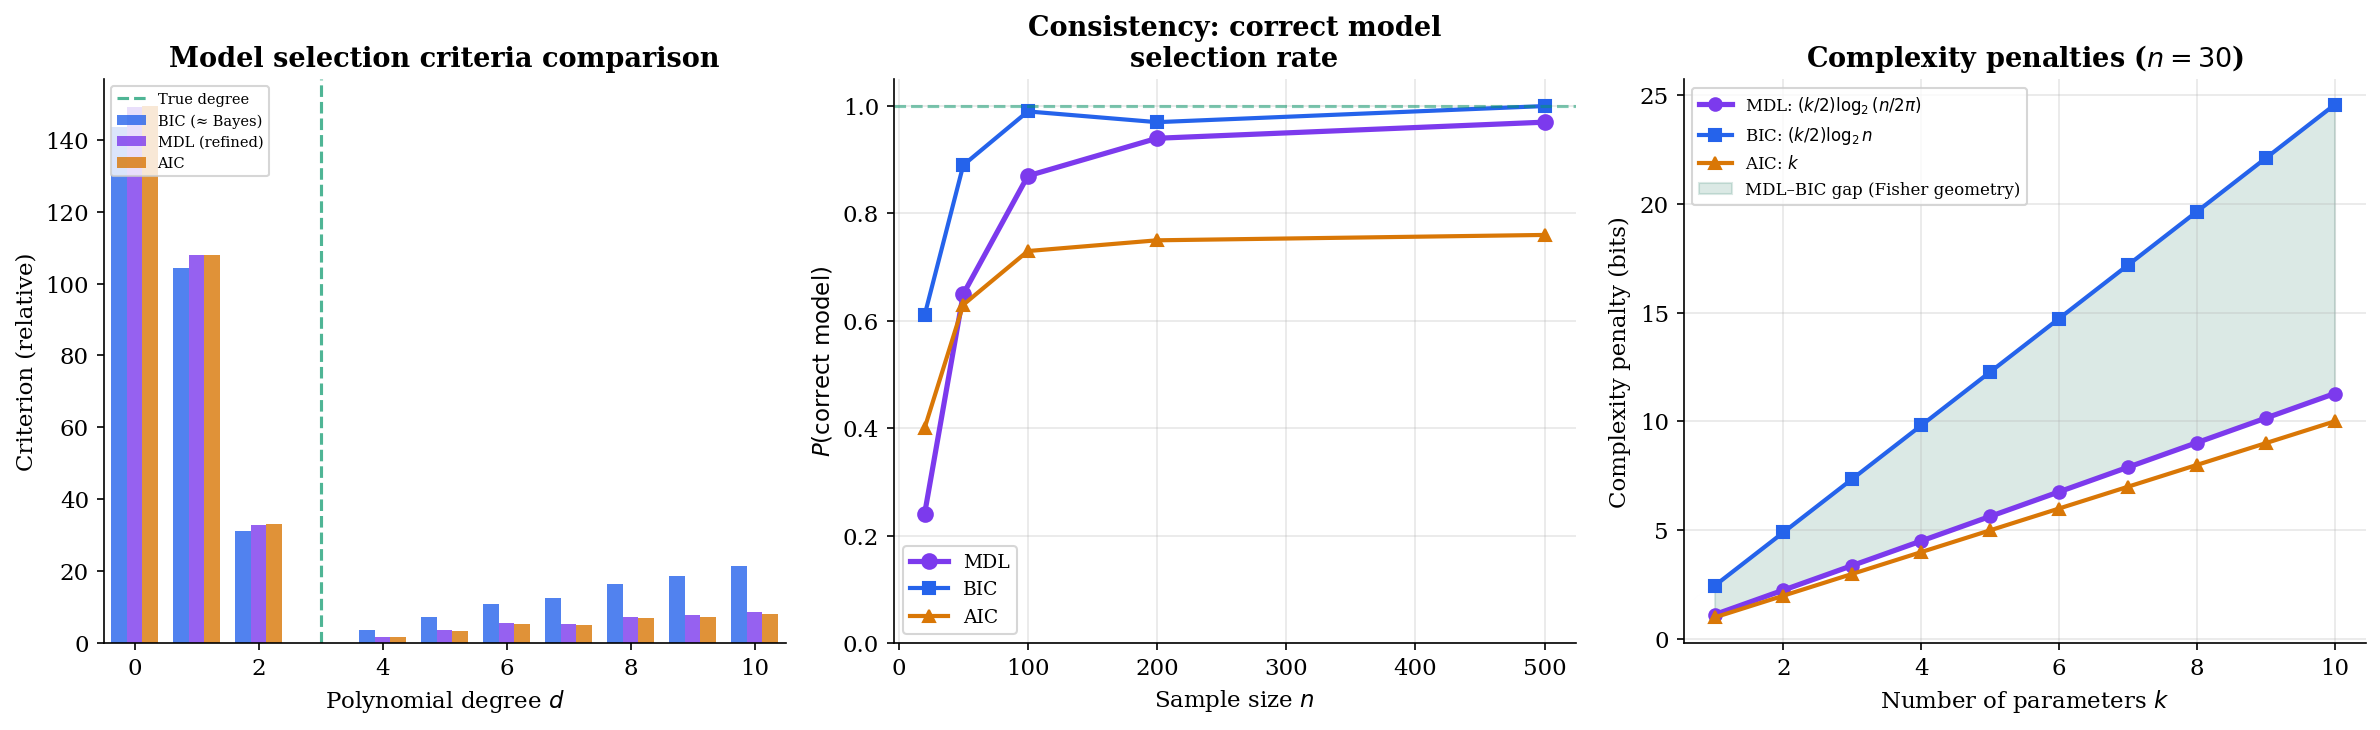

In [6]:
# === MDL and Bayesian Model Selection ===
# MDL and Bayesian model selection both penalize complexity, but from
# different philosophical starting points. Understanding their relationship
# illuminates the foundations of model selection.
#
# ──────────────────────────────────────────────────────────────────────────
# Theorem 4 (Bayesian Marginal Likelihood and Stochastic Complexity).
# The Bayesian marginal likelihood under Jeffreys prior equals:
#
#     p_J(x^n | M_k) = ∫ p(x^n | θ) π_J(θ) dθ
#
# where π_J(θ) ∝ √det I(θ). Asymptotically:
#
#     -log p_J(x^n | M_k) = -log p(x^n | θ̂) + (k/2) log(n/(2π))
#                           + log ∫ √det I(θ) dθ + o(1)
#                          = SC(x^n ; M_k) + o(1)
#
# CONCLUSION: With Jeffreys prior, the negative log marginal likelihood
# converges to the stochastic complexity. MDL and Bayes agree asymptotically
# under the least-informative prior.
# ──────────────────────────────────────────────────────────────────────────
#
# KEY DIFFERENCES despite asymptotic equivalence:
#
# 1. MDL does not require a prior — it derives complexity from coding theory
# 2. MDL is defined for individual sequences; Bayes requires a likelihood
# 3. For misspecified models, MDL (NML) remains well-defined; Bayes may not
# 4. For finite samples, MDL (NML) achieves minimax regret; Bayes
#    achieves Bayes-optimal risk under the chosen prior
#
# ──────────────────────────────────────────────────────────────────────────
# Proposition 3 (Consistency of MDL).
# Under regularity conditions, if the true distribution P* belongs to
# model class M_{k*} but not to any smaller class, then MDL is consistent:
#
#     P(MDL selects M_{k*}) → 1   as n → ∞
#
# This follows because the stochastic complexity penalty is O(k log n),
# which grows slower than the log-likelihood gain O(n) from adding a
# necessary parameter.
# ──────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: MDL vs Bayesian model selection on same data ---
ax = axes[0]
# Compare: BIC (≈ MDL), Bayes factor (Jeffreys), and AIC
# on polynomial regression with true degree 3

# Compute log marginal likelihoods under Jeffreys prior (BIC approximation)
# and compare model rankings
max_d2 = 10
d_range2 = np.arange(0, max_d2 + 1)

# Use BIC as Bayes proxy and MDL (refined)
bic2 = []
mdl2 = []  # stochastic complexity
aic2 = []

for d in d_range2:
    k = d + 2  # polynomial coefficients + variance
    coeffs = np.polyfit(x, y, d)
    y_fit = np.polyval(coeffs, x)
    rss = np.sum((y - y_fit) ** 2)
    sigma2_hat = rss / n
    log_lik = -0.5 * n * (np.log(2 * np.pi * sigma2_hat) + 1)
    
    bic2.append(-2 * log_lik + k * np.log(n))
    aic2.append(-2 * log_lik + 2 * k)
    mdl2.append(-2 * log_lik + k * np.log(n / (2 * np.pi)))

bic2 = np.array(bic2) - min(bic2)
mdl2 = np.array(mdl2) - min(mdl2)
aic2 = np.array(aic2) - min(aic2)

width = 0.25
ax.bar(d_range2 - width, bic2, width, color=BLUE, alpha=0.8, label='BIC (≈ Bayes)')
ax.bar(d_range2, mdl2, width, color=PURPLE, alpha=0.8, label='MDL (refined)')
ax.bar(d_range2 + width, aic2, width, color=AMBER, alpha=0.8, label='AIC')
ax.axvline(x=3, color=GREEN, linestyle='--', linewidth=1.5, alpha=0.7, label='True degree')
ax.set_xlabel('Polynomial degree $d$')
ax.set_ylabel('Criterion (relative)')
ax.set_title('Model selection criteria comparison', fontweight='bold')
ax.legend(fontsize=7, loc='upper left')
ax.set_xlim(-0.5, max_d2 + 0.5)

# --- Panel 2: Consistency simulation ---
ax = axes[1]
# Show that MDL consistently selects the true model as n grows
sample_sizes = [20, 50, 100, 200, 500]
n_trials = 100

mdl_correct = []
aic_correct = []
bic_correct = []

for ns_trial in sample_sizes:
    mdl_count = 0
    aic_count = 0
    bic_count = 0
    
    for _ in range(n_trials):
        x_trial = np.linspace(-1, 1, ns_trial)
        y_trial = sum(c * x_trial**i for i, c in enumerate(true_coeffs)) + rng.normal(0, sigma_noise, ns_trial)
        
        best_mdl_d = 0
        best_aic_d = 0
        best_bic_d = 0
        best_mdl_val = np.inf
        best_aic_val = np.inf
        best_bic_val = np.inf
        
        for d in range(8):
            k = d + 2
            coeffs_t = np.polyfit(x_trial, y_trial, d)
            y_fit_t = np.polyval(coeffs_t, x_trial)
            rss_t = np.sum((y_trial - y_fit_t) ** 2)
            sigma2_t = rss_t / ns_trial
            ll = -0.5 * ns_trial * (np.log(2 * np.pi * sigma2_t) + 1)
            
            v_bic = -2 * ll + k * np.log(ns_trial)
            v_aic = -2 * ll + 2 * k
            v_mdl = -2 * ll + k * np.log(ns_trial / (2 * np.pi))
            
            if v_bic < best_bic_val:
                best_bic_val, best_bic_d = v_bic, d
            if v_aic < best_aic_val:
                best_aic_val, best_aic_d = v_aic, d
            if v_mdl < best_mdl_val:
                best_mdl_val, best_mdl_d = v_mdl, d
        
        if best_mdl_d == 3: mdl_count += 1
        if best_aic_d == 3: aic_count += 1
        if best_bic_d == 3: bic_count += 1
    
    mdl_correct.append(mdl_count / n_trials)
    aic_correct.append(aic_count / n_trials)
    bic_correct.append(bic_count / n_trials)

ax.plot(sample_sizes, mdl_correct, 'o-', color=PURPLE, linewidth=2.5, markersize=7, label='MDL')
ax.plot(sample_sizes, bic_correct, 's-', color=BLUE, linewidth=2, markersize=6, label='BIC')
ax.plot(sample_sizes, aic_correct, '^-', color=AMBER, linewidth=2, markersize=6, label='AIC')
ax.axhline(y=1.0, color=GREEN, linestyle='--', alpha=0.5)

ax.set_xlabel('Sample size $n$')
ax.set_ylabel('$P(\mathrm{correct\ model})$')
ax.set_title('Consistency: correct model\nselection rate', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# --- Panel 3: When MDL and Bayes disagree ---
ax = axes[2]
# Small-sample behavior: MDL (minimax) vs Bayes (average case)
# The key difference is in the complexity penalty
ks_compare = np.arange(1, 11)
n_small = 30

# MDL complexity: (k/2) log(n/(2π))
mdl_penalty = 0.5 * ks_compare * np.log2(n_small / (2 * np.pi))

# BIC complexity: (k/2) log(n)
bic_penalty = 0.5 * ks_compare * np.log2(n_small)

# AIC complexity: k (no dependence on n)
aic_penalty = ks_compare.astype(float)

ax.plot(ks_compare, mdl_penalty, 'o-', color=PURPLE, linewidth=2.5, label='MDL: $(k/2)\log_2(n/2\pi)$')
ax.plot(ks_compare, bic_penalty, 's-', color=BLUE, linewidth=2, label='BIC: $(k/2)\log_2 n$')
ax.plot(ks_compare, aic_penalty, '^-', color=AMBER, linewidth=2, label='AIC: $k$')

ax.fill_between(ks_compare, mdl_penalty, bic_penalty, alpha=0.15, color=TEAL,
                label='MDL–BIC gap (Fisher geometry)')
ax.set_xlabel('Number of parameters $k$')
ax.set_ylabel('Complexity penalty (bits)')
ax.set_title(f'Complexity penalties ($n={n_small}$)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mdl_vs_bayes.png', dpi=150, bbox_inches='tight')
plt.show()


---

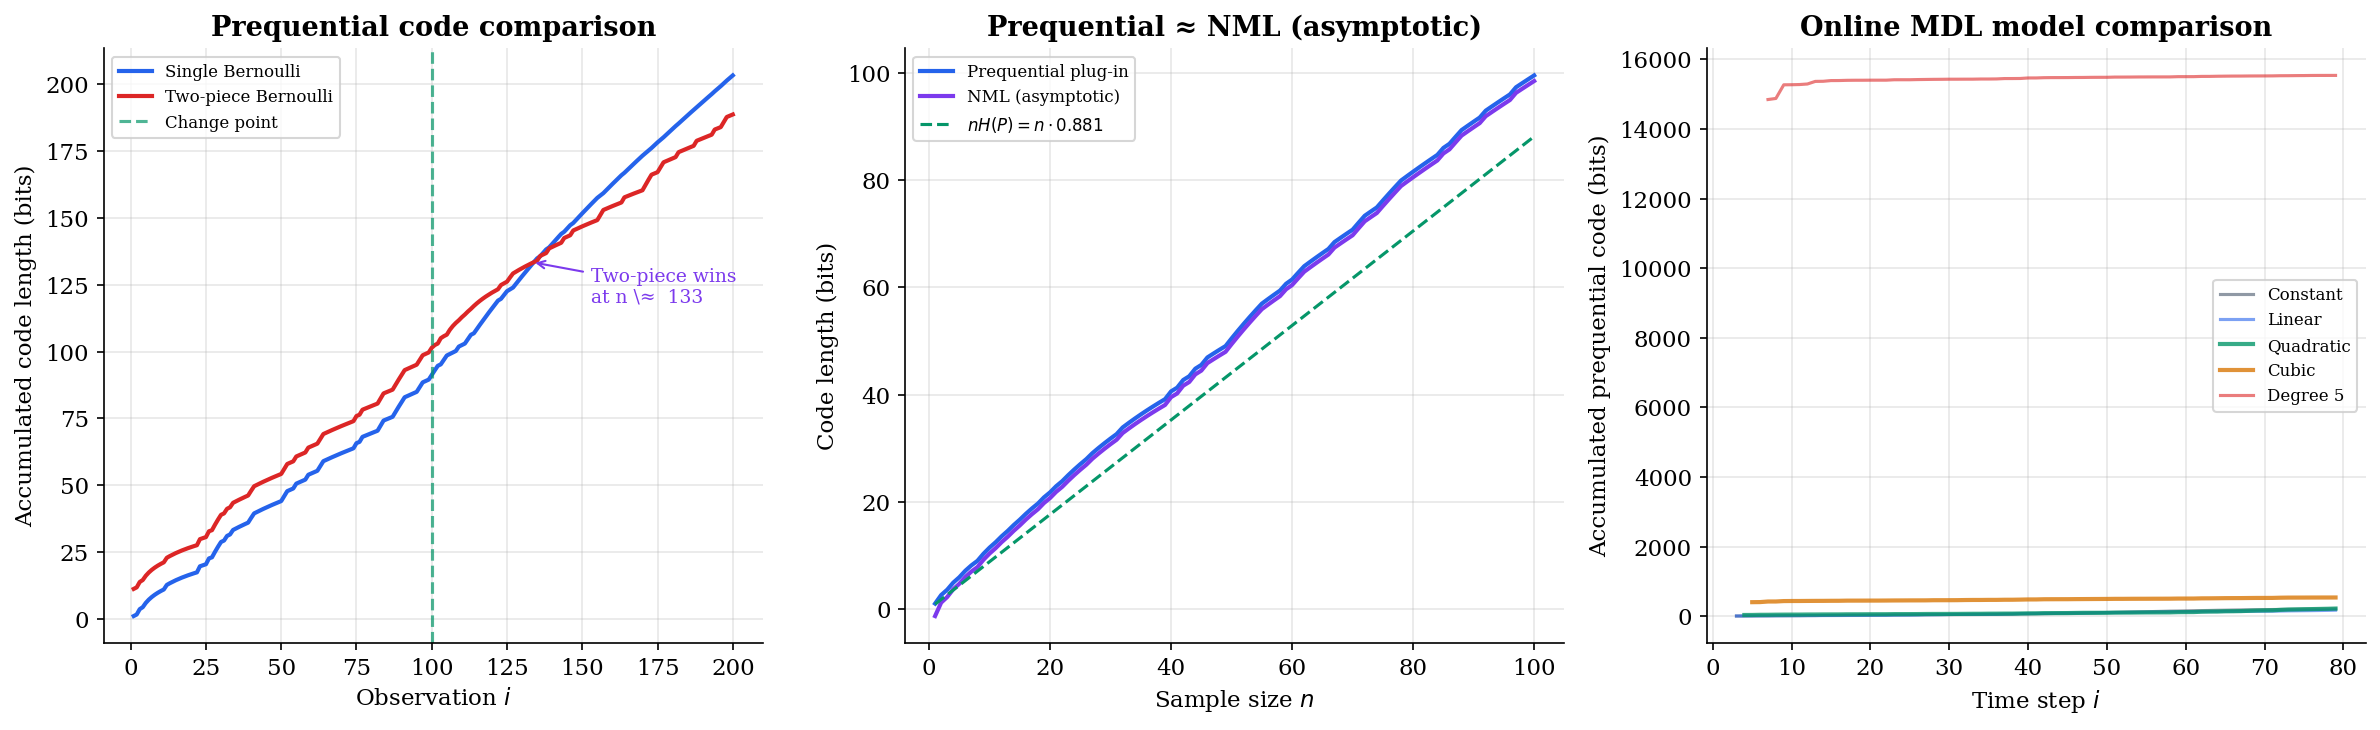

In [7]:
# === Prequential Codes & Online MDL ===
# A powerful alternative to NML: instead of coding all data at once,
# we code data points SEQUENTIALLY using a prediction-based code.
#
# ──────────────────────────────────────────────────────────────────────────
# Definition 6 (Prequential Code / Predictive MDL).
# The prequential (predictive) code length for x^n = (x_1, ..., x_n)
# under model M with prediction strategy q is:
#
#     L_pre(x^n) = -Σ_{i=1}^{n} log₂ q(x_i | x^{i-1})
#
# where q(x_i | x^{i-1}) is the predictive distribution for x_i given
# all previous observations.
# ──────────────────────────────────────────────────────────────────────────
#
# For a parametric model, the PREQUENTIAL PLUG-IN code uses the MLE
# trained on past data:
#
#     q_plug(x_i | x^{i-1}) = p(x_i | θ̂(x^{i-1}), M)
#
# ──────────────────────────────────────────────────────────────────────────
# Theorem 5 (Prequential Code and Stochastic Complexity).
# For regular parametric models, the prequential plug-in code satisfies:
#
#     L_pre(x^n) = -log p(x^n | θ̂(x^n)) + (k/2) log n + O(1)
#                = SC(x^n) + O(1)
#
# asymptotically as n → ∞. The prequential code thus achieves the same
# complexity penalty as the NML code, without requiring computation of
# the parametric complexity COMP.
# ──────────────────────────────────────────────────────────────────────────
#
# ADVANTAGES of prequential MDL over NML:
# 1. Always computable (NML's COMP can be intractable for complex models)
# 2. Online: processes data sequentially, ideal for streaming applications
# 3. Avoids the "normalization problem" that plagues NML for unbounded
#    parameter spaces (e.g., linear regression without known variance)
#
# ──────────────────────────────────────────────────────────────────────────
# Proposition 4 (Prequential Code via Bayes Mixture).
# If we use the Bayesian predictive distribution as the sequential code:
#
#     q_Bayes(x_i | x^{i-1}) = ∫ p(x_i | θ) π(θ | x^{i-1}) dθ
#
# then by the chain rule of probability:
#
#     L_pre(x^n) = -log p_Bayes(x^n) = -log ∫ p(x^n | θ) π(θ) dθ
#
# The prequential Bayes code equals the negative log marginal likelihood.
# ──────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Prequential code for Bernoulli with different models ---
ax = axes[0]
# Generate Bernoulli sequence with change point
n_seq = 200
p_before = 0.3
p_after = 0.7
change_point = 100

sequence = np.concatenate([
    rng.binomial(1, p_before, change_point),
    rng.binomial(1, p_after, n_seq - change_point)
])

# Compute accumulated prequential code length under two models:
# Model 1: single Bernoulli (no change point)
# Model 2: two-piece Bernoulli (with change point at t)

# Model 1: plug-in using Laplace smoothing θ̂ = (k+1)/(n+2)
preq_single = np.zeros(n_seq)
for i in range(n_seq):
    if i == 0:
        theta_pred = 0.5  # uniform prediction for first observation
    else:
        k_so_far = np.sum(sequence[:i])
        theta_pred = (k_so_far + 1) / (i + 2)  # Laplace smoothing
    
    if sequence[i] == 1:
        preq_single[i] = -np.log2(max(theta_pred, 1e-15))
    else:
        preq_single[i] = -np.log2(max(1 - theta_pred, 1e-15))

cum_single = np.cumsum(preq_single)

# Model 2: oracle two-piece (knows change point at 100)
preq_two = np.zeros(n_seq)
for i in range(n_seq):
    if i < change_point:
        if i == 0:
            theta_pred = 0.5
        else:
            k_so_far = np.sum(sequence[:i])
            theta_pred = (k_so_far + 1) / (i + 2)
    else:
        # Reset after change point
        idx = i - change_point
        if idx == 0:
            theta_pred = 0.5
        else:
            k_so_far = np.sum(sequence[change_point:i])
            theta_pred = (k_so_far + 1) / (idx + 2)
    
    if sequence[i] == 1:
        preq_two[i] = -np.log2(max(theta_pred, 1e-15))
    else:
        preq_two[i] = -np.log2(max(1 - theta_pred, 1e-15))

# Add model overhead for two-piece: L*(2) + log₂(n) for the change point
model_overhead = log_star(2) + np.log2(n_seq)
cum_two = np.cumsum(preq_two) + model_overhead

ax.plot(range(1, n_seq + 1), cum_single, color=BLUE, linewidth=2, label='Single Bernoulli')
ax.plot(range(1, n_seq + 1), cum_two, color=RED, linewidth=2, label='Two-piece Bernoulli')
ax.axvline(x=change_point, color=GREEN, linestyle='--', linewidth=1.5, alpha=0.7, label='Change point')

# Find crossing point
crossing = np.argmax(cum_single > cum_two)
if crossing > 0:
    ax.annotate(f'Two-piece wins\nat n \≈  {crossing}',
                xy=(crossing, cum_two[crossing]),
                xytext=(crossing + 20, cum_two[crossing] - 15),
                arrowprops=dict(arrowstyle='->', color=PURPLE), fontsize=9, color=PURPLE)

ax.set_xlabel('Observation $i$')
ax.set_ylabel('Accumulated code length (bits)')
ax.set_title('Prequential code comparison', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Panel 2: Prequential vs NML code length ---
ax = axes[1]
# For i.i.d. Bernoulli(0.3), compare prequential and NML accumulated costs
n_compare = 100
p_iid = 0.3
data_iid = rng.binomial(1, p_iid, n_compare)

# Prequential plug-in
preq_iid = np.zeros(n_compare)
for i in range(n_compare):
    if i == 0:
        theta_pred = 0.5
    else:
        theta_pred = (np.sum(data_iid[:i]) + 1) / (i + 2)
    preq_iid[i] = -np.log2(theta_pred if data_iid[i] == 1 else 1 - theta_pred)
cum_preq = np.cumsum(preq_iid)

# NML accumulated: -log p_NML(x^n) at each n
cum_nml = np.zeros(n_compare)
for ni in range(1, n_compare + 1):
    k_ni = int(np.sum(data_iid[:ni]))
    # MLE log-likelihood
    if k_ni == 0 or k_ni == ni:
        ll_mle = 0.0
    else:
        theta_mle = k_ni / ni
        ll_mle = k_ni * np.log2(theta_mle) + (ni - k_ni) * np.log2(1 - theta_mle)
    
    # COMP approximation
    log_comp = 0.5 * np.log2(ni / (2 * np.pi))
    cum_nml[ni - 1] = -ll_mle + log_comp

# Shannon entropy rate
H_rate = -(p_iid * np.log2(p_iid) + (1 - p_iid) * np.log2(1 - p_iid))
optimal = H_rate * np.arange(1, n_compare + 1)

ax.plot(range(1, n_compare + 1), cum_preq, color=BLUE, linewidth=2, label='Prequential plug-in')
ax.plot(range(1, n_compare + 1), cum_nml, color=PURPLE, linewidth=2, label='NML (asymptotic)')
ax.plot(range(1, n_compare + 1), optimal, '--', color=GREEN, linewidth=1.5, label=f'$nH(P) = n \cdot {H_rate:.3f}$')

ax.set_xlabel('Sample size $n$')
ax.set_ylabel('Code length (bits)')
ax.set_title('Prequential ≈ NML (asymptotic)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Panel 3: Online model selection ---
ax = axes[2]
# Online MDL: at each time step, compare accumulated code lengths
# across models and select the current best

# Three models: constant, linear, quadratic — for sequential regression
n_online = 80
x_online = np.linspace(0, 2 * np.pi, n_online)
y_online = 2 * np.sin(x_online) + rng.normal(0, 0.5, n_online)

cum_codes = {0: np.zeros(n_online), 1: np.zeros(n_online), 2: np.zeros(n_online), 
             3: np.zeros(n_online), 5: np.zeros(n_online)}

for d in cum_codes.keys():
    for i in range(max(d + 2, 3), n_online):  # need at least d+2 points to fit
        # Fit on past data
        coeffs_fit = np.polyfit(x_online[:i], y_online[:i], d)
        y_pred = np.polyval(coeffs_fit, x_online[i])
        sigma2_past = np.mean((y_online[:i] - np.polyval(coeffs_fit, x_online[:i]))**2)
        sigma2_past = max(sigma2_past, 0.01)
        
        # Predictive log-loss
        log_loss = 0.5 * np.log2(2 * np.pi * sigma2_past) + (y_online[i] - y_pred)**2 / (2 * sigma2_past * np.log(2))
        cum_codes[d][i] = cum_codes[d][i-1] + log_loss
    
    # Add model complexity overhead
    cum_codes[d] += log_star(d + 1)

colors_online = {0: SLATE, 1: BLUE, 2: GREEN, 3: AMBER, 5: RED}
labels_online = {0: 'Constant', 1: 'Linear', 2: 'Quadratic', 3: 'Cubic', 5: 'Degree 5'}

for d in cum_codes.keys():
    start = max(d + 2, 3)
    ax.plot(range(start, n_online), cum_codes[d][start:], color=colors_online[d],
            linewidth=2 if d in [2, 3] else 1.5, alpha=0.8 if d in [2, 3] else 0.6,
            label=labels_online[d])

ax.set_xlabel('Time step $i$')
ax.set_ylabel('Accumulated prequential code (bits)')
ax.set_title('Online MDL model comparison', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mdl_prequential.png', dpi=150, bbox_inches='tight')
plt.show()


---

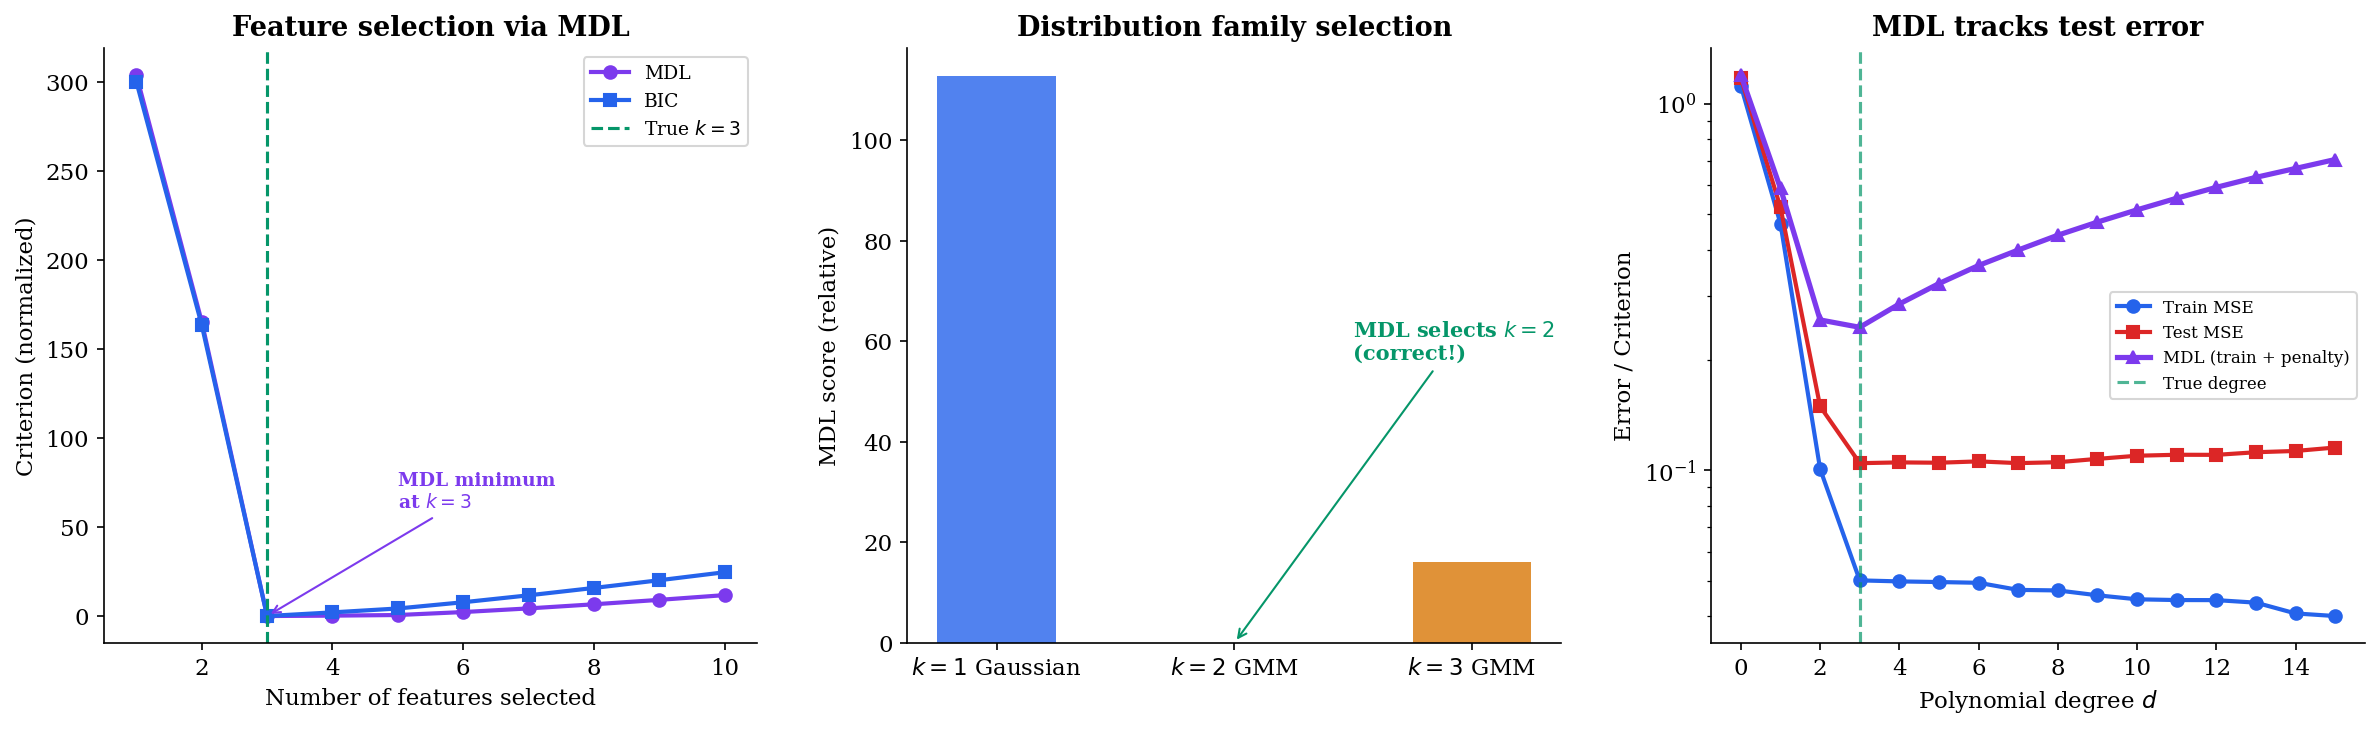

In [8]:
# === MDL for Practical Model Selection ===
# We now demonstrate MDL on concrete ML model selection problems, showing
# how the principle applies beyond polynomial regression.
#
# ──────────────────────────────────────────────────────────────────────────
# Theorem 6 (MDL and Consistent Model Selection).
# Consider nested model classes M_1 ⊂ M_2 ⊂ ... and let M_{k*} be the
# smallest class containing the true distribution. If the MDL criterion
# uses a complexity penalty satisfying:
#
#   (i)   c(k, n) / n → 0        (penalty grows slower than n)
#   (ii)  c(k, n) → ∞            (penalty diverges)
#   (iii) c(k+1, n) - c(k, n) → ∞ (penalty separates models)
#
# then MDL is consistent: P(k̂_MDL = k*) → 1 as n → ∞.
#
# Both BIC (c = k log n / 2) and refined MDL (c = (k/2) log(n/2π) +
# Fisher correction) satisfy these conditions. AIC (c = k) does NOT
# satisfy (ii) and is therefore inconsistent (tends to overfit).
# ──────────────────────────────────────────────────────────────────────────
#
# ──────────────────────────────────────────────────────────────────────────
# Proposition 5 (MDL for Linear Regression).
# For Gaussian linear regression with k predictors, the MDL criterion is:
#
#     MDL(k) = (n/2) log(RSS_k / n) + (k/2) log n + const
#
# This is equivalent to minimizing BIC. The (k/2) log n term penalizes
# each additional predictor by (1/2) log n bits.
# ──────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Feature selection via MDL ---
ax = axes[0]
# Generate data with 3 true features out of 10
n_feat = 100
p_total = 10
p_true_features = 3

# True coefficients
beta_true = np.zeros(p_total)
beta_true[:p_true_features] = [2.0, -1.5, 1.0]  # only first 3 are nonzero

X_feat = rng.normal(0, 1, (n_feat, p_total))
y_feat = X_feat @ beta_true + rng.normal(0, 0.5, n_feat)

# Forward selection with MDL criterion
selected = []
remaining = list(range(p_total))
mdl_trajectory = []
bic_trajectory = []

for step in range(p_total):
    best_feat = None
    best_mdl = np.inf
    best_bic = np.inf
    
    for feat in remaining:
        trial_features = selected + [feat]
        X_trial = X_feat[:, trial_features]
        
        # OLS fit
        beta_hat = np.linalg.lstsq(X_trial, y_feat, rcond=None)[0]
        y_pred = X_trial @ beta_hat
        rss = np.sum((y_feat - y_pred) ** 2)
        k = len(trial_features) + 1  # features + intercept + variance
        
        ll = -0.5 * n_feat * np.log(2 * np.pi * rss / n_feat) - n_feat / 2
        mdl_val = -2 * ll + k * np.log(n_feat / (2 * np.pi))
        bic_val = -2 * ll + k * np.log(n_feat)
        
        if mdl_val < best_mdl:
            best_mdl = mdl_val
            best_bic = bic_val
            best_feat = feat
    
    selected.append(best_feat)
    remaining.remove(best_feat)
    mdl_trajectory.append(best_mdl)
    bic_trajectory.append(best_bic)

mdl_trajectory = np.array(mdl_trajectory) - min(mdl_trajectory)
bic_trajectory = np.array(bic_trajectory) - min(bic_trajectory)

ax.plot(range(1, p_total + 1), mdl_trajectory, 'o-', color=PURPLE, linewidth=2, label='MDL')
ax.plot(range(1, p_total + 1), bic_trajectory, 's-', color=BLUE, linewidth=2, label='BIC')

# Mark the true number of features
ax.axvline(x=p_true_features, color=GREEN, linestyle='--', linewidth=1.5, label=f'True $k = {p_true_features}$')
mdl_best = np.argmin(mdl_trajectory) + 1
ax.annotate(f'MDL minimum\nat $k = {mdl_best}$',
            xy=(mdl_best, mdl_trajectory[mdl_best - 1]),
            xytext=(mdl_best + 2, mdl_trajectory[mdl_best - 1] + max(mdl_trajectory) * 0.2),
            arrowprops=dict(arrowstyle='->', color=PURPLE),
            fontsize=9, color=PURPLE, fontweight='bold')

ax.set_xlabel('Number of features selected')
ax.set_ylabel('Criterion (normalized)')
ax.set_title('Feature selection via MDL', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0.5, p_total + 0.5)

# --- Panel 2: MDL for distribution family selection ---
ax = axes[1]
# Generate data from a mixture of two Gaussians
# Compare: single Gaussian vs 2-component GMM vs 3-component GMM

n_gmm = 200
data_gmm = np.concatenate([
    rng.normal(-2, 0.8, n_gmm // 2),
    rng.normal(2, 0.8, n_gmm // 2)
])

from scipy.stats import norm as sp_norm

# Model 1: single Gaussian
mu1, sigma1 = np.mean(data_gmm), np.std(data_gmm)
ll1 = np.sum(sp_norm.logpdf(data_gmm, mu1, sigma1))
mdl_1 = -2 * ll1 + 2 * np.log(n_gmm)  # k=2 (μ, σ)

# Model 2: 2-component GMM (fit via EM — use simple k-means init)
from scipy.optimize import minimize as sp_minimize

def gmm_log_likelihood(data, mus, sigmas, weights):
    ll = 0
    for x in data:
        p = sum(w * sp_norm.pdf(x, m, s) for m, s, w in zip(mus, sigmas, weights))
        ll += np.log(max(p, 1e-300))
    return ll

# Simple EM for 2 components
mus2 = np.array([-2.0, 2.0])
sigmas2 = np.array([1.0, 1.0])
weights2 = np.array([0.5, 0.5])

for _ in range(50):
    # E-step
    resps = np.zeros((n_gmm, 2))
    for j in range(2):
        resps[:, j] = weights2[j] * sp_norm.pdf(data_gmm, mus2[j], sigmas2[j])
    resps /= resps.sum(axis=1, keepdims=True) + 1e-300
    
    # M-step
    Nk = resps.sum(axis=0)
    weights2 = Nk / n_gmm
    mus2 = (resps * data_gmm[:, None]).sum(axis=0) / Nk
    sigmas2 = np.sqrt(((resps * (data_gmm[:, None] - mus2)**2).sum(axis=0)) / Nk)

ll2 = gmm_log_likelihood(data_gmm, mus2, sigmas2, weights2)
mdl_2 = -2 * ll2 + 5 * np.log(n_gmm)  # k=5 (2μ, 2σ, 1 weight)

# Model 3: 3-component GMM
mus3 = np.array([-2.0, 0.0, 2.0])
sigmas3 = np.array([1.0, 1.0, 1.0])
weights3 = np.array([1/3, 1/3, 1/3])

for _ in range(50):
    resps3 = np.zeros((n_gmm, 3))
    for j in range(3):
        resps3[:, j] = weights3[j] * sp_norm.pdf(data_gmm, mus3[j], sigmas3[j])
    resps3 /= resps3.sum(axis=1, keepdims=True) + 1e-300
    
    Nk3 = resps3.sum(axis=0)
    weights3 = Nk3 / n_gmm
    mus3 = (resps3 * data_gmm[:, None]).sum(axis=0) / Nk3
    sigmas3 = np.sqrt(((resps3 * (data_gmm[:, None] - mus3)**2).sum(axis=0)) / Nk3)

ll3 = gmm_log_likelihood(data_gmm, mus3, sigmas3, weights3)
mdl_3 = -2 * ll3 + 8 * np.log(n_gmm)  # k=8 (3μ, 3σ, 2 weights)

models = ['$k=1$ Gaussian', '$k=2$ GMM', '$k=3$ GMM']
mdl_scores = np.array([mdl_1, mdl_2, mdl_3])
mdl_scores -= mdl_scores.min()

bars = ax.bar(models, mdl_scores, color=[BLUE, GREEN, AMBER], alpha=0.8, width=0.5)
ax.annotate('MDL selects $k=2$\n(correct!)', xy=(1, mdl_scores[1]),
            xytext=(1.5, max(mdl_scores) * 0.5),
            arrowprops=dict(arrowstyle='->', color=GREEN),
            fontsize=10, color=GREEN, fontweight='bold')

ax.set_ylabel('MDL score (relative)')
ax.set_title('Distribution family selection', fontweight='bold')

# --- Panel 3: Overfitting detection ---
ax = axes[2]
# Show how MDL detects overfitting in polynomial regression
# by tracking train error vs MDL penalty vs test error

d_overfit = np.arange(0, 16)
x_test = np.linspace(-1, 1, 200)
y_test = sum(c * x_test**i for i, c in enumerate(true_coeffs)) + rng.normal(0, sigma_noise, 200)

train_errors = []
test_errors = []
mdl_penalties = []

for d in d_overfit:
    coeffs_o = np.polyfit(x, y, d)
    y_train_pred = np.polyval(coeffs_o, x)
    y_test_pred = np.polyval(coeffs_o, x_test)
    
    train_mse = np.mean((y - y_train_pred)**2)
    test_mse = np.mean((y_test - y_test_pred)**2)
    penalty = (d + 2) * np.log(n) / (2 * n)  # normalized BIC penalty
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    mdl_penalties.append(train_mse + penalty)

ax.semilogy(d_overfit, train_errors, 'o-', color=BLUE, linewidth=2, label='Train MSE')
ax.semilogy(d_overfit, test_errors, 's-', color=RED, linewidth=2, label='Test MSE')
ax.semilogy(d_overfit, mdl_penalties, '^-', color=PURPLE, linewidth=2.5, label='MDL (train + penalty)')

ax.axvline(x=3, color=GREEN, linestyle='--', linewidth=1.5, alpha=0.7, label='True degree')

ax.set_xlabel('Polynomial degree $d$')
ax.set_ylabel('Error / Criterion')
ax.set_title('MDL tracks test error', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('mdl_practical.png', dpi=150, bbox_inches='tight')
plt.show()


---

In [9]:
# === Computational Notes ===
# Practical MDL implementations in Python for common model selection tasks.
#
# ──────────────────────────────────────────────────────────────────────────
# Remark 1 (BIC as the Practical MDL).
# For most applications, BIC = -2 log L(θ̂) + k log n is the simplest
# implementation of MDL. It captures the dominant (k/2) log n complexity
# term and is available in every statistical software package.
#
# Use BIC when:
#   - Models are nested or comparable
#   - n is large relative to k
#   - You want consistency (BIC is consistent; AIC is not)
#
# Use refined MDL (NML / prequential) when:
#   - n is small relative to k
#   - The Fisher information geometry matters (curved models)
#   - You need individual-sequence guarantees (worst-case, not average)
# ──────────────────────────────────────────────────────────────────────────
#
# ──────────────────────────────────────────────────────────────────────────
# Remark 2 (MDL and Regularization).
# MDL connects to regularization: the two-part code L(M) + L(D|M)
# is equivalent to penalized maximum likelihood:
#
#     θ̂_MDL = arg min_θ [-log p(D|θ) + λ ||θ||₀]
#
# where λ = (1/2) log n (BIC penalty) and ||θ||₀ counts nonzero parameters.
# This is L0-regularized regression — the information-theoretic basis
# for sparse model selection.
# ──────────────────────────────────────────────────────────────────────────
#
# ──────────────────────────────────────────────────────────────────────────
# Remark 3 (MDL and Neural Network Compression).
# For neural networks, the two-part code becomes:
#   L(M) = description length of the network architecture + quantized weights
#   L(D|M) = cross-entropy loss on training data
#
# This is the foundation of NEURAL NETWORK PRUNING and QUANTIZATION:
# removing weights (reducing L(M)) at the cost of slightly increasing
# L(D|M), while reducing total description length.
#
# The "lottery ticket hypothesis" can be interpreted through MDL: a sparse
# subnetwork achieves shorter total description length than the dense
# original, because the reduction in L(M) outweighs the increase in L(D|M).
# ──────────────────────────────────────────────────────────────────────────

# === Implementation: MDL for linear regression model selection ===
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

def mdl_linear_regression(X, y, max_features=None):
    """MDL-based feature selection for linear regression.
    
    Uses BIC as the MDL criterion:
        MDL(k) = n log(RSS_k / n) + k log(n)
    
    Returns the selected feature indices and MDL scores.
    """
    n, p = X.shape
    if max_features is None:
        max_features = p
    
    results = []
    for k in range(1, max_features + 1):
        # Forward selection: add the best feature at each step
        if k == 1:
            best_score = np.inf
            best_features = []
            for j in range(p):
                model = LinearRegression().fit(X[:, [j]], y)
                rss = np.sum((y - model.predict(X[:, [j]]))**2)
                mdl_score = n * np.log(rss / n) + (k + 1) * np.log(n)
                if mdl_score < best_score:
                    best_score = mdl_score
                    best_features = [j]
        else:
            best_score_step = np.inf
            best_new_feat = None
            for j in range(p):
                if j not in best_features:
                    trial = best_features + [j]
                    model = LinearRegression().fit(X[:, trial], y)
                    rss = np.sum((y - model.predict(X[:, trial]))**2)
                    mdl_score = n * np.log(rss / n) + (len(trial) + 1) * np.log(n)
                    if mdl_score < best_score_step:
                        best_score_step = mdl_score
                        best_new_feat = j
            
            best_features = best_features + [best_new_feat]
            best_score = best_score_step
        
        results.append({
            'k': k,
            'features': list(best_features),
            'mdl_score': best_score
        })
    
    # Select model with minimum MDL
    best_result = min(results, key=lambda r: r['mdl_score'])
    return best_result, results

# Demo: apply to our feature selection problem
best_model, all_results = mdl_linear_regression(X_feat, y_feat)
print(f"MDL selected {best_model['k']} features: {best_model['features']}")
print(f"True nonzero features: {list(range(p_true_features))}")
print()

# === Implementation: BIC for GMM component selection ===
from scipy.stats import norm as sp_norm2

def bic_gmm_selection(data, max_components=5, n_em_iter=50):
    """Select number of GMM components using BIC (≈ MDL)."""
    n = len(data)
    results = []
    
    for K in range(1, max_components + 1):
        # Initialize
        mus = np.linspace(data.min(), data.max(), K)
        sigmas = np.full(K, data.std())
        weights = np.full(K, 1.0 / K)
        
        # EM
        for _ in range(n_em_iter):
            # E-step
            resps = np.zeros((n, K))
            for j in range(K):
                resps[:, j] = weights[j] * sp_norm2.pdf(data, mus[j], max(sigmas[j], 0.01))
            resps /= resps.sum(axis=1, keepdims=True) + 1e-300
            
            # M-step
            Nk = resps.sum(axis=0) + 1e-10
            weights = Nk / n
            mus = (resps * data[:, None]).sum(axis=0) / Nk
            sigmas = np.sqrt(((resps * (data[:, None] - mus)**2).sum(axis=0)) / Nk)
        
        # Log-likelihood
        ll = sum(np.log(max(sum(weights[j] * sp_norm2.pdf(x, mus[j], max(sigmas[j], 0.01))
                              for j in range(K)), 1e-300)) for x in data)
        
        k_params = 3 * K - 1  # K means + K variances + (K-1) weights
        bic = -2 * ll + k_params * np.log(n)
        
        results.append({'K': K, 'BIC': bic, 'log_lik': ll, 'k_params': k_params})
        print(f"  K={K}: log L = {ll:.1f}, k = {k_params}, BIC = {bic:.1f}")
    
    best = min(results, key=lambda r: r['BIC'])
    return best, results

print("GMM component selection via BIC (MDL):")
best_gmm, gmm_results = bic_gmm_selection(data_gmm, max_components=5)
print(f"\nBIC selects K = {best_gmm['K']} components")
print()

# === Summary table ===
print("=" * 70)
print("MDL Criteria Summary")
print("=" * 70)
print(f"{'Criterion':<20} {'Penalty':<30} {'Consistent?':<12}")
print("-" * 70)
print(f"{'AIC':<20} {'2k':<30} {'No':<12}")
print(f"{'BIC (≈ crude MDL)':<20} {'k log n':<30} {'Yes':<12}")
print(f"{'Refined MDL':<20} {'(k/2)log(n/2π) + Fisher':<30} {'Yes':<12}")
print(f"{'NML':<20} {'log COMP(M)':<30} {'Yes':<12}")
print(f"{'Prequential':<20} {'Online accumulated loss':<30} {'Yes':<12}")
print("=" * 70)


MDL selected 3 features: [0, 1, 2]
True nonzero features: [0, 1, 2]

GMM component selection via BIC (MDL):
  K=1: log L = -437.5, k = 2, BIC = 885.6
  K=2: log L = -373.2, k = 5, BIC = 772.9
  K=3: log L = -373.3, k = 8, BIC = 789.1
  K=4: log L = -373.1, k = 11, BIC = 804.4
  K=5: log L = -373.1, k = 14, BIC = 820.4

BIC selects K = 2 components

MDL Criteria Summary
Criterion            Penalty                        Consistent? 
----------------------------------------------------------------------
AIC                  2k                             No          
BIC (≈ crude MDL)    k log n                        Yes         
Refined MDL          (k/2)log(n/2π) + Fisher        Yes         
NML                  log COMP(M)                    Yes         
Prequential          Online accumulated loss        Yes         


---

## Connections & Further Reading

### Connection Map

| Topic | Relationship |
|-------|-------------|
| [Shannon Entropy & Mutual Information](/topics/shannon-entropy) | MDL formalizes source coding for model selection: the shortest description length equals the entropy $H(P)$ under the true model. Shannon's source coding theorem underpins the coding interpretation of MDL. |
| [KL Divergence & f-Divergences](/topics/kl-divergence) | The regret of a universal code is bounded by $D_{\mathrm{KL}}(p_{\theta^*} \| p_{\mathrm{NML}})$. The stochastic complexity decomposes into the maximized log-likelihood plus the KL divergence from the NML distribution to the MLE model. |
| [Rate-Distortion Theory](/topics/rate-distortion) | Rate-distortion theory and MDL are dual perspectives on compression: rate-distortion minimizes bits for a fidelity constraint, while MDL uses total description length for model selection. The information bottleneck connects both viewpoints. |
| [Convex Analysis](/topics/convex-analysis) | The NML optimization is a minimax problem solved by convex duality. The parametric complexity integral involves the Fisher information geometry, connecting to the convex structure of exponential families. |
| [Information Geometry & Fisher Metric](/topics/information-geometry) | The asymptotic parametric complexity $\log \mathrm{COMP}$ involves $\int \sqrt{\det I(\theta)} \, d\theta$ — the volume of the model manifold in the Fisher metric. MDL model complexity has a geometric interpretation as the "size" of the model in information space. |
| **PAC Learning & Computational Learning Theory** *(coming soon)* | MDL and PAC learning provide complementary perspectives on generalization: MDL penalizes model complexity via description length, while PAC bounds generalization error via VC dimension. Occam's razor lemma connects both: short descriptions imply small generalization error. |

### Notation Reference

| Symbol | Meaning |
|--------|---------|
| $L(M)$ | Code length for model $M$ (complexity) |
| $L(D \mid M)$ | Code length for data $D$ given model $M$ (goodness-of-fit) |
| $L^*(k)$ | Rissanen's universal code for positive integer $k$ |
| $K(x)$ | Kolmogorov complexity of string $x$ |
| $\mathrm{SC}(x^n; M_k)$ | Stochastic complexity of $x^n$ under model $M_k$ |
| $p_{\mathrm{NML}}$ | Normalized Maximum Likelihood distribution |
| $\mathrm{COMP}(M_k)$ | Parametric complexity: $\sum_{z^n} p(z^n \mid \hat{\theta}(z^n))$ |
| $I(\theta)$ | Fisher information matrix at parameter $\theta$ |
| $\hat{\theta}(x^n)$ | Maximum likelihood estimator for data $x^n$ |
| $L_{\mathrm{pre}}(x^n)$ | Prequential (predictive) code length |
| BIC | Bayesian Information Criterion: $-2 \log L + k \log n$ |

### References

1. **Rissanen** (1978). "Modeling by Shortest Data Description." *Automatica*, 14(5), 465–471. The foundational paper introducing the MDL principle.
2. **Rissanen** (2007). *Information and Complexity in Statistical Modeling*. Springer. The definitive monograph on refined MDL and stochastic complexity.
3. **Grünwald** (2007). *The Minimum Description Length Principle*. MIT Press. The most comprehensive textbook on MDL, covering theory and applications.
4. **Barron, Rissanen & Yu** (1998). "The Minimum Description Length Principle in Coding and Modeling." *IEEE Trans. Information Theory*, 44(6), 2743–2760.
5. **Grünwald & Roos** (2020). "Minimum Description Length Revisited." *International Journal of Mathematics for Industry*. https://doi.org/10.1142/S2661335219300018. Modern survey of MDL with connections to deep learning.
6. **Li & Vitányi** (2019). *An Introduction to Kolmogorov Complexity and Its Applications*, 4th ed. Springer. The standard reference on algorithmic information theory.
